# Desafío Colsubsidio · Data Scientist — Notebook integrado (Retos 1, 2 y 3)

Este notebook documenta, **celda por celda**, el proceso completo de los tres retos: exploración de datos, decisiones metodológicas, modelado y resultados.

| Parte | Reto | Tipo | Archivo de datos |
|---|---|---|---|
| 1 | Estimar el **aporte mensual** de cada empresa | Regresión | `empresas_afiliadas.csv` |
| 2 | **Riesgo de desafiliación** | Clasificación | `base_clasificacion.csv` (separador `;`) |
| 3 | **Proyección del recaudo** 2026 y presupuesto | Series de tiempo | `dataset_recaudo.xlsx` |

**Cómo usarlo**
1. Instala dependencias: `pip install -r requirements.txt`.
2. Deja los tres archivos de datos en la misma carpeta del notebook (o cambia `DATA_DIR` en la celda 0).
3. Ejecuta de arriba abajo (*Run All*) o una celda a la vez. Todo es determinístico (semilla 42). Tiempo total aproximado: 5–8 minutos.

**Convención en cada parte:** *Objetivo → Exploración → Decisión → Modelado → Resultado → Limitaciones*. Las celdas marcadas con **🔎 Decisión** explican por qué se eligió un camino y no otro.

## 0. Configuración común

In [5]:
import os, warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 40, "display.width", 160, "display.float_format", "{:,.4f}".format)

SEED = 42
# Carpeta con los datos. Cámbiala si los archivos están en otro lugar.
DATA_DIR = Path(os.environ.get("DATA_DIR", "."))
archivos = [
    ("Datos Reto 1", "empresas_afiliadas.csv"),
    ("Datos Reto 2", "base_clasificacion.csv"),
    ("Datos Reto 3", "dataset_recaudo.xlsx"),
]
for carpeta, archivo in archivos:
    ruta_archivo = DATA_DIR / carpeta / archivo
    existe = ruta_archivo.exists()
    
    # Imprimimos la verificación
    print(f"{f'{carpeta}/{archivo}':40s}", "OK" if existe else "NO ENCONTRADO")

Datos Reto 1/empresas_afiliadas.csv      OK
Datos Reto 2/base_clasificacion.csv      OK
Datos Reto 3/dataset_recaudo.xlsx        OK


---
# PARTE 1 · Reto 1 — Estimación del aporte mensual de las empresas afiliadas

**Pregunta de negocio:** ¿cuánto aportará cada empresa al mes y qué factores explican las diferencias?
Sirve para planear financieramente y priorizar acciones comerciales.

**Supuestos** (también en el informe):
- S1. Cada fila es una empresa única y `aporte_mensual` está en COP del mismo período.
- S2. No hay dimensión temporal: el modelo es **transversal** (no es un pronóstico en el tiempo).
- S3. `salario_promedio` se interpreta en millones de COP.
- S4. `satisfaccion_servicio` y `numero_servicios` se conocen al momento de predecir. Si se miden *después* del aporte habría que retirarlas.
- S5. Los valores extremos (empresas grandes) son reales y se conservan.

## 1.1 Carga y control de calidad

In [2]:
TARGET1 = "aporte_mensual"
CAT1 = ["ciudad", "sector"]

raw1 = pd.read_csv(DATA_DIR / "empresas_afiliadas.csv", encoding="utf-8-sig")   # utf-8-sig por el BOM del archivo

# Controles automáticos: si algo falla, el notebook se detiene aquí en vez de producir resultados engañosos
assert raw1["id_empresa"].is_unique, "id_empresa duplicado"
assert raw1.isna().sum().sum() == 0, "Hay nulos: definir estrategia de imputación"
assert (raw1[TARGET1] > 0).all() and (raw1["numero_trabajadores"] > 0).all()

print(f"{raw1.shape[0]:,} empresas × {raw1.shape[1]} columnas | sin nulos ni duplicados")
raw1.head()

10,000 empresas × 16 columnas | sin nulos ni duplicados


,id_empresa,ciudad,sector,antiguedad_empresa,distancia_centro,productividad,numero_trabajadores,salario_promedio,rotacion_personal,crecimiento_nomina,numero_servicios,indice_formalizacion,indice_digitalizacion,indice_competencia,satisfaccion_servicio,aporte_mensual
0,1,Bogotá,Hoteles,9.8000,52.2500,48.1000,2,3.5300,24.2000,-5.4000,1,74.3000,62.3000,31.7000,5.7000,"6,119,147.0000"
1,2,Medellín,Construcción,17.5000,58.8100,54.2000,29,4.0900,23.1000,2.7000,1,60.6000,71.5000,1.9000,6.0000,"10,689,409.0000"
2,3,Otras,Minas,7.3000,71.7800,88.7000,3,4.8700,13.6000,0.5000,1,80.2000,64.2000,82.0000,6.4000,"10,001,511.0000"
3,4,Bogotá,Energía,3.4000,50.5700,65.7000,3,4.7700,11.7000,5.6000,1,69.3000,66.8000,48.1000,6.1000,"8,243,634.0000"
4,5,Medellín,Financiero,22.0000,4.9300,66.7000,5,4.8700,6.5000,0.9000,0,73.7000,71.2000,47.7000,5.8000,"7,935,528.0000"


In [3]:
raw1.describe().T

,count,mean,std,min,25%,50%,75%,max
id_empresa,"10,000.0000","5,000.5000","2,886.8957",1.0000,"2,500.7500","5,000.5000","7,500.2500","10,000.0000"
antiguedad_empresa,"10,000.0000",13.1072,10.5285,1.0000,6.0000,9.9000,16.7000,60.0000
distancia_centro,"10,000.0000",39.9678,23.0790,0.0000,20.0500,39.7250,60.1225,80.0000
productividad,"10,000.0000",60.8105,10.8149,17.6000,53.3000,60.6000,68.3000,95.0000
numero_trabajadores,"10,000.0000",20.9564,24.3994,1.0000,7.0000,14.0000,25.0000,353.0000
salario_promedio,"10,000.0000",4.0174,0.8330,1.5000,3.4300,3.9600,4.5800,7.0700
rotacion_personal,"10,000.0000",20.2019,7.8879,0.0000,14.8000,20.7000,26.0000,45.6000
crecimiento_nomina,"10,000.0000",6.0004,6.0357,-15.0000,2.0000,6.0000,10.0000,29.1000
numero_servicios,"10,000.0000",1.2561,1.1538,0.0000,0.0000,1.0000,2.0000,10.0000
indice_formalizacion,"10,000.0000",66.3647,8.3352,31.3000,60.6000,66.3000,71.9000,100.0000


In [4]:
print("Ciudades :", raw1["ciudad"].nunique(), "| Sectores:", raw1["sector"].nunique())
raw1["sector"].value_counts()

Ciudades : 9 | Sectores: 12


sector
Comercio         2788
Manufactura      1401
Información       838
Transporte        827
Profesionales     779
Construcción      747
Hoteles           609
Agricultura       577
Financiero        562
Salud             460
Minas             230
Energía           182
Name: count, dtype: int64

## 1.2 Exploración: la variable objetivo

Los aportes de empresas pequeñas y grandes difieren en órdenes de magnitud. Veamos la forma de la distribución.

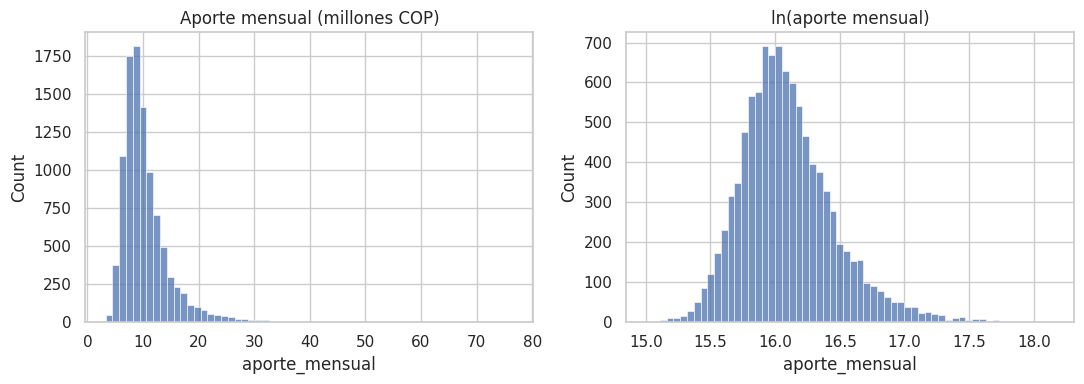

Asimetría: 3.30  ->  en logaritmo: 0.86


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(raw1[TARGET1] / 1e6, bins=60, ax=ax[0]).set(title="Aporte mensual (millones COP)")
sns.histplot(np.log(raw1[TARGET1]), bins=60, ax=ax[1]).set(title="ln(aporte mensual)")
plt.tight_layout(); plt.show()
print(f"Asimetría: {raw1[TARGET1].skew():.2f}  ->  en logaritmo: {np.log(raw1[TARGET1]).skew():.2f}")

> **🔎 Decisión 1 — modelar el logaritmo del aporte.**
> La distribución original tiene cola larga a la derecha (asimetría 3,3). En log queda casi simétrica (0,86).
> *Por qué importa al negocio:* para planeación importa el **error relativo** ("me equivoqué 4%") más que el absoluto, y el aporte se comporta de forma multiplicativa (una empresa con el doble de nómina aporta ~el doble). Entrenar en log hace que el modelo se equivoque en proporción, no en pesos, y evita que unas pocas empresas gigantes dominen el ajuste.

## 1.3 Exploración: relaciones con el aporte

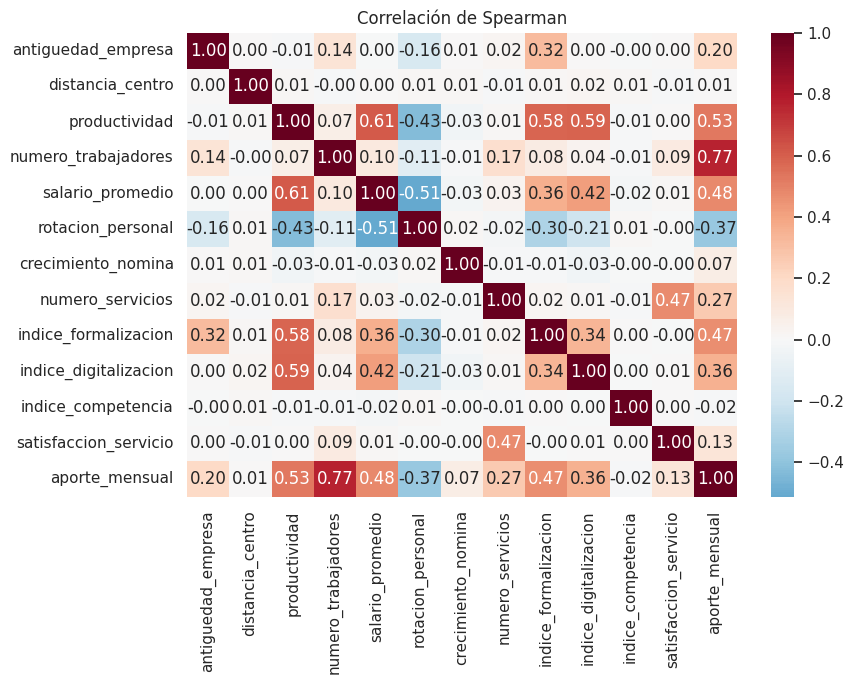

rotacion_personal       -0.3723
indice_competencia      -0.0152
distancia_centro         0.0051
crecimiento_nomina       0.0748
satisfaccion_servicio    0.1262
antiguedad_empresa       0.1976
numero_servicios         0.2659
indice_digitalizacion    0.3586
indice_formalizacion     0.4674
salario_promedio         0.4774
productividad            0.5312
numero_trabajadores      0.7685
Name: aporte_mensual, dtype: float64

In [6]:
num_cols1 = raw1.select_dtypes("number").drop(columns=["id_empresa"]).columns
corr1 = raw1[num_cols1].corr(method="spearman")      # Spearman: robusta a la asimetría
plt.figure(figsize=(9, 7)); sns.heatmap(corr1, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlación de Spearman"); plt.tight_layout(); plt.show()
corr1[TARGET1].drop(TARGET1).sort_values()

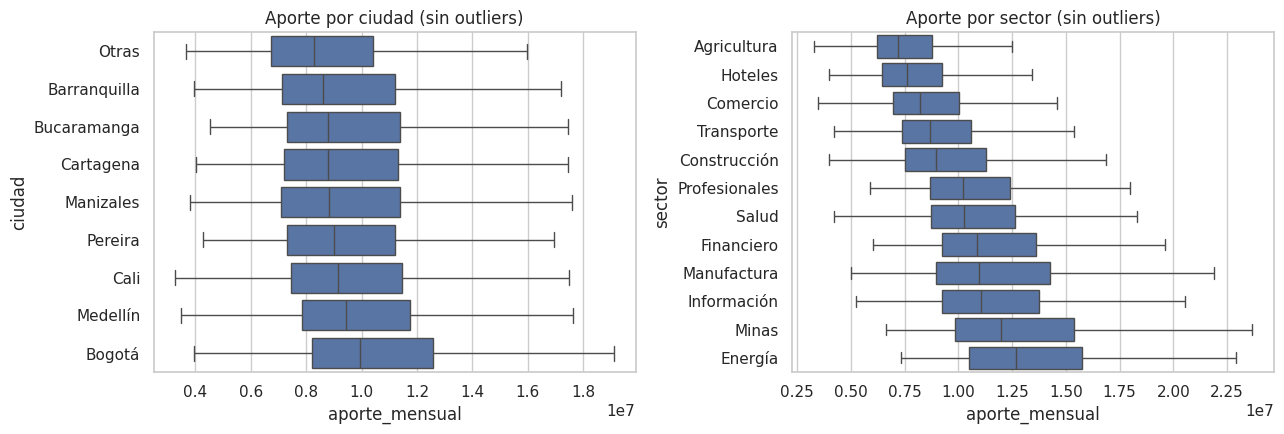

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, c in zip(ax, CAT1):
    orden = raw1.groupby(c)[TARGET1].median().sort_values().index
    sns.boxplot(data=raw1, y=c, x=TARGET1, order=orden, ax=a, showfliers=False)
    a.set_title(f"Aporte por {c} (sin outliers)")
plt.tight_layout(); plt.show()

**Lectura:** el tamaño (trabajadores) y la masa salarial están fuertemente asociados al aporte. Los sectores sí parecen tener medianas distintas, pero cuidado: puede ser un efecto de *composición* (sectores con empresas más grandes). Lo comprobaremos en 1.9 controlando por tamaño.

## 1.4 Ingeniería de variables

- `ln_trabajadores`: el tamaño es muy asimétrico; el log linealiza su relación con el aporte.
- `ln_nomina_total` = ln(trabajadores × salario): proxy de la masa salarial, base natural del aporte.
- **No** se crea "aporte por trabajador": usaría el objetivo y generaría *fuga de información*.

In [8]:
def crear_variables_1(df):
    """Misma función para entrenamiento y producción (evita desajustes)."""
    out = df.copy()
    out["ln_trabajadores"] = np.log(out["numero_trabajadores"])
    out["ln_nomina_total"] = np.log(out["numero_trabajadores"] * out["salario_promedio"])
    out["tiene_servicios"] = (out["numero_servicios"] > 0).astype(int)
    for c in CAT1:
        out[c] = out[c].astype("category")
    return out

df1 = crear_variables_1(raw1)
y1 = np.log(df1[TARGET1])
X1 = df1.drop(columns=["id_empresa", TARGET1])
X1.dtypes

ciudad                   category
sector                   category
antiguedad_empresa        float64
distancia_centro          float64
productividad             float64
numero_trabajadores         int64
salario_promedio          float64
rotacion_personal         float64
crecimiento_nomina        float64
numero_servicios            int64
indice_formalizacion      float64
indice_digitalizacion     float64
indice_competencia        float64
satisfaccion_servicio     float64
ln_trabajadores           float64
ln_nomina_total           float64
tiene_servicios             int64
dtype: object

## 1.5 Partición de datos: 70% entrenamiento · 10% calibración · 20% prueba

- Se **estratifica por deciles del aporte** para que train y test tengan la misma cola de empresas grandes.
- El set de **calibración** (no usado para ajustar) sirve para corregir sesgo e intervalos.
- El **test se usa una sola vez**, al final.

In [9]:
from sklearn.model_selection import train_test_split

estrato = pd.qcut(y1, 10, labels=False)
X_tmp, X_te1, y_tmp, y_te1 = train_test_split(X1, y1, test_size=0.20, random_state=SEED, stratify=estrato)
X_tr1, X_cal1, y_tr1, y_cal1 = train_test_split(X_tmp, y_tmp, test_size=0.125, random_state=SEED,
                                                stratify=estrato.loc[X_tmp.index])
print(f"Train {len(X_tr1):,} | Calibración {len(X_cal1):,} | Test {len(X_te1):,}")

Train 7,000 | Calibración 1,000 | Test 2,000


## 1.6 Comparación de modelos (validación cruzada 5-fold, solo sobre train)

Candidatos, de simple a complejo: **baseline** (mediana) → **Ridge** (lineal) → **Random Forest** → **XGBoost** → **LightGBM**.
El baseline fija el piso: cualquier modelo que no lo supere con holgura no sirve.

In [10]:
import lightgbm as lgb, xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_validate, cross_val_predict, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score)

num1 = [c for c in X1.columns if c not in CAT1]
pre_lin1 = ColumnTransformer([("n", StandardScaler(), num1), ("c", OneHotEncoder(handle_unknown="ignore"), CAT1)])
pre_tree1 = ColumnTransformer([("n", "passthrough", num1), ("c", OneHotEncoder(handle_unknown="ignore"), CAT1)])

modelos1 = {
    "Baseline (mediana)": Pipeline([("p", pre_lin1), ("m", DummyRegressor(strategy="median"))]),
    "Ridge (log-lineal)": Pipeline([("p", pre_lin1), ("m", RidgeCV(alphas=np.logspace(-3, 3, 20)))]),
    "Random Forest": Pipeline([("p", pre_tree1), ("m", RandomForestRegressor(300, min_samples_leaf=5, n_jobs=-1, random_state=SEED))]),
    "XGBoost": Pipeline([("p", pre_tree1), ("m", xgb.XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=4,
                          subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=-1))]),
    "LightGBM": lgb.LGBMRegressor(n_estimators=600, learning_rate=0.03, num_leaves=15, min_child_samples=30,
                                  subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=SEED, verbose=-1),
}
cv1 = KFold(5, shuffle=True, random_state=SEED)
filas = []
for nombre, mod in modelos1.items():
    r = cross_validate(mod, X_tr1, y_tr1, cv=cv1, scoring=("neg_root_mean_squared_error", "r2"), n_jobs=1)
    filas.append({"modelo": nombre, "RMSE_log_cv": -r["test_neg_root_mean_squared_error"].mean(),
                  "desv": r["test_neg_root_mean_squared_error"].std(), "R2_log_cv": r["test_r2"].mean()})
comp1 = pd.DataFrame(filas).sort_values("RMSE_log_cv").reset_index(drop=True)
comp1

,modelo,RMSE_log_cv,desv,R2_log_cv
0,XGBoost,0.0699,0.0035,0.9634
1,LightGBM,0.0716,0.0040,0.9616
2,Random Forest,0.0799,0.0030,0.9522
3,Ridge (log-lineal),0.0864,0.0033,0.9441
4,Baseline (mediana),0.3683,0.0090,-0.0162


> **🔎 Decisión 2 — árboles potenciados como candidatos; se afina LightGBM.**
> XGBoost y LightGBM quedan prácticamente empatados (RMSE en log ≈ 0,070 vs 0,072, dentro de una desviación entre folds) y ambos superan con claridad al Random Forest y al Ridge. Se afina **LightGBM** por rapidez de reentrenamiento y por manejar las categorías de forma nativa; con otro de los dos el resultado sería equivalente.
> Un RMSE en log de ~0,07 equivale a un error de ~7% (el RMSE pesa más los errores grandes; el MAPE en test es ~4%). El Ridge (~0,086) queda como **referencia explicable**: es razonable, pero los modelos de árboles reducen su error en pesos en ~30% (ver 1.8), lo que indica no linealidades que el modelo lineal no captura.

## 1.7 Ajuste fino del modelo y corrección de sesgo log → pesos

In [11]:
espacio = {"num_leaves": [7, 15, 31], "min_child_samples": [10, 20, 40, 80], "learning_rate": [0.02, 0.03, 0.05],
           "n_estimators": [400, 700, 1000], "reg_lambda": [0, 1, 5, 10], "colsample_bytree": [0.6, 0.8, 1.0]}
busq1 = RandomizedSearchCV(modelos1["LightGBM"], espacio, n_iter=15, cv=cv1, random_state=SEED,
                           scoring="neg_root_mean_squared_error", n_jobs=1).fit(X_tr1, y_tr1)
final1 = busq1.best_estimator_
print("Mejores hiperparámetros:", busq1.best_params_)
print(f"RMSE_log CV del modelo ajustado: {-busq1.best_score_:.4f}")

Mejores hiperparámetros: {'reg_lambda': 5, 'num_leaves': 15, 'n_estimators': 1000, 'min_child_samples': 10, 'learning_rate': 0.02, 'colsample_bytree': 0.8}
RMSE_log CV del modelo ajustado: 0.0701


In [12]:
# Un modelo entrenado en log y exponenciado devuelve la MEDIANA, no la media: subestima el total.
# Corrección de Duan ("smearing"), estimada con residuos del set de CALIBRACIÓN (no usado para ajustar).
res_cal1 = y_cal1 - final1.predict(X_cal1)
smearing = float(np.mean(np.exp(res_cal1)))
print(f"Factor de corrección (smearing): {smearing:.4f}  (aprox. +{(smearing-1)*100:.1f}% sobre exp(pred))")

Factor de corrección (smearing): 1.0016  (aprox. +0.2% sobre exp(pred))


## 1.8 Evaluación final en el set de prueba (se usa una sola vez)

In [13]:
def metricas_reg(y_log_real, y_log_pred, smearing=1.0):
    real, pred = np.exp(y_log_real), np.exp(y_log_pred) * smearing
    return {"R2_log": r2_score(y_log_real, y_log_pred),
            "RMSE_log": mean_squared_error(y_log_real, y_log_pred) ** 0.5,
            "MAE_COP": mean_absolute_error(real, pred),
            "MAPE": mean_absolute_percentage_error(real, pred),
            "WAPE": np.abs(real - pred).sum() / real.sum(),          # error ponderado por monto
            "R2_COP": r2_score(real, pred),
            "Sesgo_total_%": 100 * (pred.sum() / real.sum() - 1)}      # clave para presupuesto

p_te1 = final1.predict(X_te1)
tabla1 = pd.DataFrame({
    "LightGBM final": metricas_reg(y_te1, p_te1, smearing),
    "Ridge (referencia)": metricas_reg(y_te1, modelos1["Ridge (log-lineal)"].fit(X_tr1, y_tr1).predict(X_te1)),
    "Baseline": metricas_reg(y_te1, modelos1["Baseline (mediana)"].fit(X_tr1, y_tr1).predict(X_te1)),
}).T
tabla1

,R2_log,RMSE_log,MAE_COP,MAPE,WAPE,R2_COP,Sesgo_total_%
LightGBM final,0.9614,0.0710,"430,165.8049",0.0390,0.0410,0.9649,0.0720
Ridge (referencia),0.9443,0.0852,"620,248.8850",0.0539,0.0592,0.9242,-0.2260
Baseline,-0.0148,0.3640,"2,970,140.3835",0.2614,0.2833,-0.0603,-11.0060


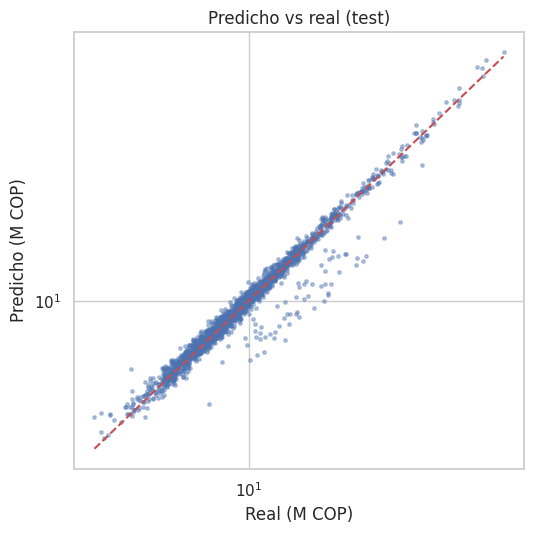

In [14]:
real, pred = np.exp(y_te1) / 1e6, np.exp(p_te1) * smearing / 1e6
plt.figure(figsize=(5.5, 5.5)); plt.scatter(real, pred, s=6, alpha=.4)
lim = [real.min(), real.max()]; plt.plot(lim, lim, "r--")
plt.xscale("log"); plt.yscale("log"); plt.xlabel("Real (M COP)"); plt.ylabel("Predicho (M COP)")
plt.title("Predicho vs real (test)"); plt.tight_layout(); plt.show()

**Lectura:**
- El error típico es de ~4% (MAPE) y el **sesgo en el total es prácticamente cero** → apto para planeación agregada.
- Frente al Ridge, LightGBM baja el MAPE de 5,4% a 3,9% y el error absoluto medio de ~620 mil a ~430 mil COP por empresa (≈ −30%): hay no linealidades que el modelo lineal no captura. Ambos superan ampliamente al baseline (MAPE 26%).

## 1.9 Intervalos de predicción y límites del modelo

Un número puntual no basta para decidir: se necesita saber cuánto puede desviarse.
Usamos **conformal split asimétrico** (cuantiles de los residuos de calibración), porque los errores tienen colas pesadas y sesgadas hacia arriba.

In [15]:
q_lo = float(np.quantile(res_cal1, 0.10, method="lower"))
q_hi = float(np.quantile(res_cal1, 0.90, method="higher"))
lo = np.exp(p_te1 + q_lo) * smearing; hi = np.exp(p_te1 + q_hi) * smearing
cobertura = float(((np.exp(y_te1) >= lo) & (np.exp(y_te1) <= hi)).mean())
print(f"Intervalo 80%: [{(np.exp(q_lo)-1)*100:+.1f}%, {(np.exp(q_hi)-1)*100:+.1f}%] alrededor de la estimación")
print(f"Cobertura real en test: {cobertura:.1%} (nominal 80%)")

Intervalo 80%: [-5.2%, +4.0%] alrededor de la estimación
Cobertura real en test: 77.3% (nominal 80%)


La cobertura real queda algo por debajo del 80% nominal. La causa son las **colas pesadas** (curtosis alta de los residuos), que se investigan a continuación.

In [16]:
# Diagnóstico de errores grandes: residuos fuera de muestra sobre TODOS los datos (5-fold)
oof1 = cross_val_predict(final1, X1, y1, cv=KFold(5, shuffle=True, random_state=SEED))
d1 = df1.assign(residuo=y1 - oof1)
atip = d1["residuo"] > 0.20                                   # aporta >20% más de lo que explican las variables

print(f"Empresas atípicas: {atip.sum()} ({atip.mean():.1%}) | residuo medio en ese grupo: {d1.loc[atip,'residuo'].mean():+.2f} (log)")
mape_sin = np.abs(np.exp(d1.loc[~atip, 'residuo']) - 1).mean()
print(f"MAPE del resto de empresas: {mape_sin:.1%}")

# ¿Se pueden predecir con las variables disponibles?
auc_atip = cross_val_score(lgb.LGBMClassifier(n_estimators=200, learning_rate=0.03, num_leaves=7, verbose=-1),
                           pd.get_dummies(X1, columns=CAT1).astype(float), atip.astype(int), cv=5, scoring="roc_auc").mean()
print(f"AUC para predecir si una empresa es atípica: {auc_atip:.2f}   (0.50 = azar)")

d1.groupby(atip)[num1].mean().T.rename(columns={False: "resto", True: "atípicas"})

Empresas atípicas: 272 (2.7%) | residuo medio en ese grupo: +0.34 (log)
MAPE del resto de empresas: 2.9%


AUC para predecir si una empresa es atípica: 0.47   (0.50 = azar)


residuo,resto,atípicas
antiguedad_empresa,13.0795,14.0978
distancia_centro,39.9502,40.5957
productividad,60.7799,61.9033
numero_trabajadores,20.8904,23.3162
salario_promedio,4.0171,4.0274
rotacion_personal,20.2082,19.9761
crecimiento_nomina,6.0015,5.9614
numero_servicios,1.2552,1.2868
indice_formalizacion,66.3421,67.1728
indice_digitalizacion,65.3687,65.4357


> **🔎 Hallazgo.** ~2,7% de las empresas aporta alrededor de **40% más** de lo que explican todas las variables disponibles, y **no se pueden anticipar** (AUC ≈ 0,5; su perfil es idéntico al resto). Esto apunta a una **variable no observada** (por ejemplo múltiples sedes, otros ingresos o un tipo de aportante distinto).
> *Acción recomendada:* preguntar al negocio qué distingue a esas empresas; incorporarlo al modelo reduciría de forma importante el error en la cola.

## 1.10 ¿Qué factores explican las diferencias en el aporte?

Tres lentes complementarios:
1. **OLS log-log** (explicativo): los coeficientes se leen como elasticidades.
2. **Permutation importance** en test: importancia honesta del modelo final.
3. **SHAP**: dirección y forma de cada efecto.

In [17]:
# Lente 1: OLS log-log con errores robustos (HC3). Controla por tamaño y salario al comparar sectores/ciudades.
cols_ols = [c for c in X1.columns if c not in ["ln_nomina_total", "tiene_servicios", "ln_trabajadores"]]
Xo = pd.get_dummies(X_tr1[cols_ols], columns=CAT1, drop_first=True).astype(float)
Xo["numero_trabajadores"] = np.log(Xo["numero_trabajadores"])
Xo["salario_promedio"] = np.log(Xo["salario_promedio"])
Xo = Xo.rename(columns={"numero_trabajadores": "ln_numero_trabajadores", "salario_promedio": "ln_salario_promedio"})
ols1 = sm.OLS(y_tr1, sm.add_constant(Xo)).fit(cov_type="HC3")
coef1 = pd.DataFrame({"coef": ols1.params, "p_valor": ols1.pvalues, "efecto_%": (np.exp(ols1.params) - 1) * 100})
print(f"R² ajustado = {ols1.rsquared_adj:.3f}  (modelo explicativo, no el de producción)")
coef1.round(4).sort_values("p_valor")

R² ajustado = 0.865  (modelo explicativo, no el de producción)


,coef,p_valor,efecto_%
const,14.0462,0.0000,"125,950,124.8492"
antiguedad_empresa,0.0016,0.0000,0.1576
productividad,0.0077,0.0000,0.7761
ln_numero_trabajadores,0.2517,0.0000,28.6261
rotacion_personal,-0.0018,0.0000,-0.1845
ln_salario_promedio,0.2638,0.0000,30.1830
crecimiento_nomina,0.0052,0.0000,0.5202
numero_servicios,0.0516,0.0000,5.2996
indice_digitalizacion,0.0021,0.0000,0.2064
indice_formalizacion,0.0060,0.0000,0.6003


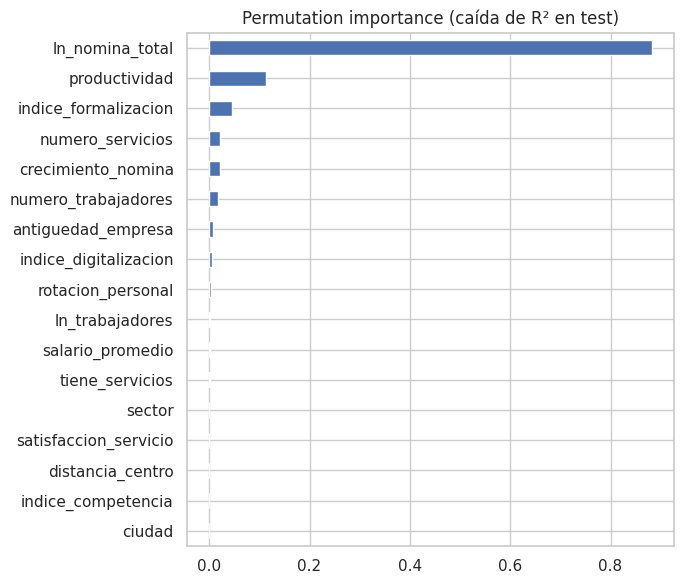

In [18]:
# Lente 2: permutation importance (caída de R² al "romper" cada variable en test)
from sklearn.inspection import permutation_importance
pi1 = permutation_importance(final1, X_te1, y_te1, n_repeats=10, random_state=SEED, n_jobs=1)
imp1 = pd.Series(pi1.importances_mean, X1.columns).sort_values()
imp1.plot.barh(figsize=(7, 6), title="Permutation importance (caída de R² en test)")
plt.tight_layout(); plt.show()

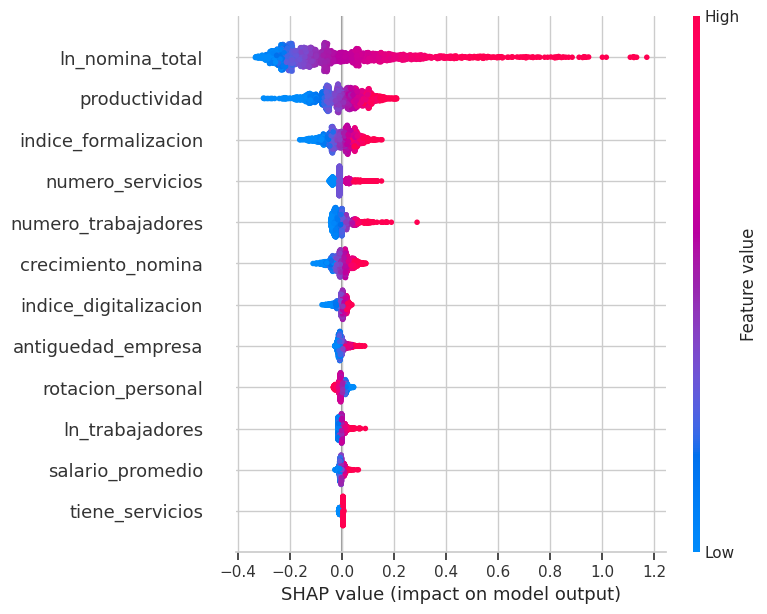

In [19]:
# Lente 3: SHAP
import shap
sv1 = shap.TreeExplainer(final1).shap_values(X_te1)
shap.summary_plot(sv1, X_te1, max_display=12)

### Conclusiones de la Parte 1

| | Resultado (test, 2.000 empresas) |
|---|---|
| Modelo final | LightGBM ajustado sobre ln(aporte), corregido por *smearing* |
| Error típico | ~4% (MAPE 3,9% · WAPE 4,1%) frente a 26% del baseline |
| Sesgo en el total | ≈ 0% (clave para presupuesto) |
| Intervalo 80% | ≈ −5% / +4% (cobertura real ~77%; para presupuesto usar 90%) |

**Factores asociados al aporte**
1. **Tamaño de la nómina** (trabajadores × salario) es el factor dominante y se comporta de forma multiplicativa.
2. **Productividad**, formalización, número de servicios, crecimiento de nómina y antigüedad aportan en segundo orden; **la rotación** se asocia negativamente.
3. **Ciudad y sector no tienen efecto propio** una vez se controla por tamaño y salario: las diferencias de mediana son de composición. *Implicación:* segmentar la estrategia comercial por perfil de empresa, no por sector o ciudad.

**Limitaciones**
- ~2,7% de empresas aportan ~40% más de lo explicable y no son predecibles con estos datos (variable no observada).
- Modelo transversal: no valida estabilidad en el tiempo; requiere monitoreo y reentrenamiento.
- Asociación, no causalidad. Importancias repartidas entre variables correlacionadas.

---
# PARTE 2 · Reto 2 — Riesgo de desafiliación de empresas

**Pregunta de negocio:** ¿qué empresas tienen mayor riesgo de retirarse y qué factores lo explican?, para que la Gerencia Comercial **priorice acciones de retención** con recursos limitados.

**Supuestos**
- S1. Cada fila es una empresa; `abandono = 1` significa retiro en la ventana observada.
- S2. Sin fechas: modelo transversal (no es una curva de supervivencia).
- S3. `id_empresa` y `nit` son identificadores: se excluyen.
- S4. `uso_servicios`, `satisfaccion` y `crecimiento_empleo` se miden **antes** del retiro. Si fuera después (una empresa que se va deja de usar servicios), habría causalidad inversa y el modelo sobreestimaría su capacidad. **Debe confirmarse con el área de datos.**
- S5. Los parámetros económicos de 2.9 (valor, costo, efectividad) son **ilustrativos**.

## 2.1 Carga y control de calidad

In [20]:
TARGET2, CAT2, IDS2 = "abandono", ["sector"], ["id_empresa", "nit"]

raw2 = pd.read_csv(DATA_DIR / "base_clasificacion.csv", sep=";", encoding="utf-8-sig")   # ¡separador ";"!
assert raw2["id_empresa"].is_unique and raw2["nit"].is_unique
assert raw2.isna().sum().sum() == 0
assert set(raw2[TARGET2].unique()) <= {0, 1}
assert (raw2["tiempo_afiliacion"] <= raw2["antiguedad"]).all(), "tiempo de afiliación mayor que la antigüedad"

tasa2 = raw2[TARGET2].mean()
print(f"{len(raw2):,} empresas | tasa de abandono: {tasa2:.1%}")
raw2.head()

10,000 empresas | tasa de abandono: 30.3%


,id_empresa,nit,sector,antiguedad,tiempo_afiliacion,num_trabajadores,crecimiento_empleo,uso_servicios,satisfaccion,rotacion,salario_promedio,digitalizacion,formalizacion,distancia,abandono
0,1,903373228,Manufactura,2.8000,1.5000,14,-5.0000,3,57.6000,27.2000,3.1300,37.0000,43.4000,26.6000,1
1,2,904494741,Manufactura,13.3000,8.1000,5,1.0000,6,71.4000,14.3000,3.9700,86.9000,64.9000,0.6000,0
2,3,867433090,Tecnología,50.0000,44.4000,60,9.7000,4,57.9000,10.7000,3.6400,51.2000,66.7000,2.3000,0
3,4,843731818,Servicios,7.0000,4.4000,15,8.8000,5,84.8000,9.4000,1.5400,73.7000,63.4000,4.9000,0
4,5,864648907,Servicios,9.5000,8.0000,48,4.1000,4,72.3000,11.1000,3.8700,60.6000,94.9000,23.3000,0


In [21]:
raw2.describe().T

,count,mean,std,min,25%,50%,75%,max
id_empresa,"10,000.0000","5,000.5000","2,886.8957",1.0000,"2,500.7500","5,000.5000","7,500.2500","10,000.0000"
nit,"10,000.0000","900,100,490.5347","57,863,309.9336","800,030,815.0000","849,925,744.0000","899,193,378.0000","950,741,801.5000","999,992,211.0000"
antiguedad,"10,000.0000",11.3757,8.2860,1.0000,5.7000,9.1000,14.4000,50.0000
tiempo_afiliacion,"10,000.0000",6.8716,6.0451,0.2000,2.9000,5.1000,8.8000,49.6000
num_trabajadores,"10,000.0000",36.7300,38.8899,5.0000,13.0000,25.0000,45.0000,500.0000
crecimiento_empleo,"10,000.0000",5.0869,10.1113,-30.0000,-1.8000,5.1000,12.0000,40.0000
uso_servicios,"10,000.0000",4.6600,2.1282,0.0000,3.0000,5.0000,6.0000,10.0000
satisfaccion,"10,000.0000",65.7905,13.8682,16.8000,56.4000,66.0000,75.2000,100.0000
rotacion,"10,000.0000",17.0656,9.5079,0.1000,9.7000,15.9000,23.1000,53.2000
salario_promedio,"10,000.0000",3.5297,1.2796,1.0000,2.6200,3.3200,4.2100,11.3600


> **🔎 Decisión 1 — no re-muestrear.**
> La tasa de abandono es 30%: desbalance moderado. Técnicas como SMOTE o *undersampling* distorsionan las probabilidades, y aquí necesitamos probabilidades **bien calibradas** para decidir a quién contactar según costo-beneficio. Se trabaja con los datos tal cual y se evalúa con métricas adecuadas (AUC, PR-AUC, log-loss, calibración).

## 2.2 Exploración: ¿cómo cambia el abandono con cada variable?

Dividimos cada variable en quintiles y miramos la tasa de abandono en el quintil más bajo vs el más alto. Es una lectura directa para el negocio.

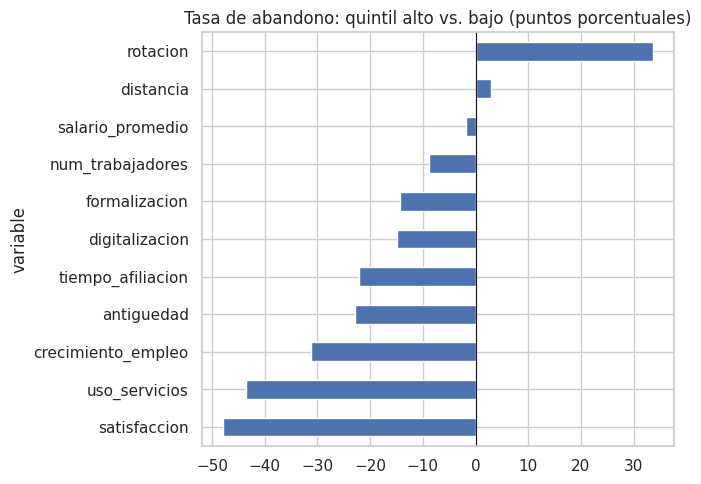

,tasa_Q1_(bajo),tasa_Q5_(alto),diferencia_pp
variable,,,
satisfaccion,0.5629,0.0847,-47.8162
uso_servicios,0.5403,0.1045,-43.5789
crecimiento_empleo,0.4728,0.1602,-31.2603
antiguedad,0.3934,0.1646,-22.8833
tiempo_afiliacion,0.3869,0.1657,-22.1192
digitalizacion,0.3809,0.2328,-14.8008
formalizacion,0.3768,0.2340,-14.2804
num_trabajadores,0.3388,0.2501,-8.8653
salario_promedio,0.3170,0.2996,-1.7427


In [22]:
num_raw2 = [c for c in raw2.columns if c not in IDS2 + [TARGET2] + CAT2]
filas = []
for c in num_raw2:
    t = raw2.groupby(pd.qcut(raw2[c], 5, duplicates="drop"), observed=True)[TARGET2].mean()
    filas.append({"variable": c, "tasa_Q1_(bajo)": t.iloc[0], "tasa_Q5_(alto)": t.iloc[-1],
                  "diferencia_pp": 100 * (t.iloc[-1] - t.iloc[0])})
eda2 = pd.DataFrame(filas).set_index("variable").sort_values("diferencia_pp")
eda2["diferencia_pp"].plot.barh(figsize=(7, 5), title="Tasa de abandono: quintil alto vs. bajo (puntos porcentuales)")
plt.axvline(0, c="k", lw=.8); plt.tight_layout(); plt.show()
eda2

In [23]:
raw2.groupby("sector")[TARGET2].agg(["mean", "count"]).sort_values("mean")

,mean,count
sector,,
Comercio,0.2910,2546
Tecnología,0.2926,499
Servicios,0.2944,3533
Transporte,0.3066,959
Manufactura,0.3141,1506
Construcción,0.3501,957


**Lectura inicial:** la rotación de personal sube el abandono; satisfacción, uso de servicios y crecimiento del empleo lo bajan fuertemente. Distancia, salario y digitalización casi no se mueven. Verificaremos si esto se sostiene en un modelo multivariado.

## 2.3 Ingeniería de variables y partición

- `ln_trabajadores`: tamaño asimétrico → log.
- `ratio_afiliacion` = tiempo de afiliación / antigüedad: ¿se afilió tarde o temprano en su vida?
- Partición 70 / 10 / 20 **estratificada por el objetivo** (mantiene el 30% en todos los sets).

In [24]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate

def crear_variables_2(df):
    out = df.drop(columns=[c for c in IDS2 + [TARGET2] if c in df.columns]).copy()
    out["ln_trabajadores"] = np.log(out["num_trabajadores"])
    out["ratio_afiliacion"] = out["tiempo_afiliacion"] / out["antiguedad"]
    out["sector"] = out["sector"].astype("category")
    return out

X2, y2 = crear_variables_2(raw2), raw2[TARGET2]
X_tmp2, X_te2, y_tmp2, y_te2 = train_test_split(X2, y2, test_size=0.20, stratify=y2, random_state=SEED)
X_tr2, X_cal2, y_tr2, y_cal2 = train_test_split(X_tmp2, y_tmp2, test_size=0.125, stratify=y_tmp2, random_state=SEED)
print(f"Train {len(X_tr2):,} | Calibración {len(X_cal2):,} | Test {len(X_te2):,} | tasa en test {y_te2.mean():.1%}")

Train 7,000 | Calibración 1,000 | Test 2,000 | tasa en test 30.3%


## 2.4 Comparación de modelos (CV 5-fold estratificado)

Orden de **complejidad creciente**: baseline → logística → logística con *splines* (captura curvas) → Random Forest → XGBoost → LightGBM ajustado.
Métricas: **AUC** (ordena bien), **PR-AUC** (precisión en la clase de interés), **log-loss y Brier** (calidad de las probabilidades).

In [25]:
import lightgbm as lgb, xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler
from sklearn.metrics import (average_precision_score, brier_score_loss, log_loss, roc_auc_score,
                             roc_curve, precision_recall_curve)
from sklearn.calibration import calibration_curve

num2 = [c for c in X2.columns if c not in CAT2]
pre_lin2 = ColumnTransformer([("n", StandardScaler(), num2), ("c", OneHotEncoder(handle_unknown="ignore"), CAT2)])
pre_spl2 = ColumnTransformer([("n", Pipeline([("s", StandardScaler()), ("sp", SplineTransformer(n_knots=5, degree=3))]), num2),
                              ("c", OneHotEncoder(handle_unknown="ignore"), CAT2)])
pre_tree2 = ColumnTransformer([("n", "passthrough", num2), ("c", OneHotEncoder(handle_unknown="ignore"), CAT2)])

cv2 = StratifiedKFold(5, shuffle=True, random_state=SEED)
espacio2 = {"num_leaves": [4, 7, 15], "min_child_samples": [20, 40, 80], "learning_rate": [0.02, 0.03, 0.05],
            "n_estimators": [200, 400, 700], "reg_lambda": [0, 5, 20], "colsample_bytree": [0.6, 0.8, 1.0]}
busq2 = RandomizedSearchCV(lgb.LGBMClassifier(subsample=0.8, subsample_freq=1, random_state=SEED, verbose=-1),
                           espacio2, n_iter=15, cv=cv2, scoring="neg_log_loss", random_state=SEED, n_jobs=1).fit(X_tr2, y_tr2)
print("LightGBM mejores hiperparámetros:", busq2.best_params_)

modelos2 = {
    "1. Baseline (tasa global)": Pipeline([("p", pre_lin2), ("m", DummyClassifier(strategy="prior"))]),
    "2. Regresión logística": Pipeline([("p", pre_lin2), ("m", LogisticRegression(C=1.0, max_iter=3000))]),
    "3. Logística + splines": Pipeline([("p", pre_spl2), ("m", LogisticRegression(C=0.3, max_iter=5000))]),
    "4. Random Forest": Pipeline([("p", pre_tree2), ("m", RandomForestClassifier(400, min_samples_leaf=20, n_jobs=-1, random_state=SEED))]),
    "5. XGBoost": Pipeline([("p", pre_tree2), ("m", xgb.XGBClassifier(n_estimators=300, learning_rate=0.03, max_depth=3,
                            subsample=0.8, colsample_bytree=0.8, min_child_weight=10, random_state=SEED, n_jobs=-1))]),
    "6. LightGBM (ajustado)": busq2.best_estimator_,
}
scoring2 = {"auc": "roc_auc", "pr": "average_precision", "ll": "neg_log_loss", "brier": "neg_brier_score"}
filas = []
for nombre, mod in modelos2.items():
    r = cross_validate(mod, X_tr2, y_tr2, cv=cv2, scoring=scoring2, n_jobs=1)
    filas.append({"modelo": nombre, "AUC": r["test_auc"].mean(), "AUC_std": r["test_auc"].std(),
                  "PR_AUC": r["test_pr"].mean(), "LogLoss": -r["test_ll"].mean(), "Brier": -r["test_brier"].mean()})
comp2 = pd.DataFrame(filas)
comp2

LightGBM mejores hiperparámetros: {'reg_lambda': 0, 'num_leaves': 4, 'n_estimators': 700, 'min_child_samples': 20, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


,modelo,AUC,AUC_std,PR_AUC,LogLoss,Brier
0,1. Baseline (tasa global),0.5000,0.0000,0.3029,0.6133,0.2111
1,2. Regresión logística,0.8746,0.0053,0.7621,0.3982,0.1277
2,3. Logística + splines,0.8751,0.0047,0.7680,0.3974,0.1277
3,4. Random Forest,0.8662,0.0069,0.7476,0.4268,0.1369
4,5. XGBoost,0.8741,0.0041,0.7660,0.3998,0.1286
5,6. LightGBM (ajustado),0.8759,0.0027,0.7708,0.3952,0.1272


> **🔎 Decisión 2 — regla de parsimonia.**
> Entre los modelos cuyo log-loss está a menos de **0,005** del mejor (diferencia sin relevancia práctica, ≈0,001 de AUC) se elige **el más simple**.
> *Por qué:* el negocio necesita **explicar** por qué una empresa está en riesgo (odds ratios, motivos por empresa) y desplegar rápido. Si un modelo complejo no gana de forma relevante, la complejidad es costo sin beneficio.

In [26]:
TOL_LOGLOSS = 0.005
mejor_ll = comp2["LogLoss"].min()
candidatos = comp2[(comp2["LogLoss"] <= mejor_ll + TOL_LOGLOSS) & (~comp2["modelo"].str.startswith("1."))]
elegido2 = candidatos.iloc[0]["modelo"]            # comp2 está ordenado de simple a complejo
print("Modelos dentro de la tolerancia:", candidatos["modelo"].tolist())
print("Modelo elegido:", elegido2)
final2 = modelos2[elegido2].fit(X_tr2, y_tr2)
es_logit2 = elegido2.startswith(("2.", "3."))

Modelos dentro de la tolerancia: ['2. Regresión logística', '3. Logística + splines', '5. XGBoost', '6. LightGBM (ajustado)']
Modelo elegido: 2. Regresión logística


## 2.5 Evaluación final en test (una sola vez) y calibración

In [27]:
def ece(y, p, bins=10):
    """Error de calibración esperado: distancia entre probabilidad predicha y frecuencia real."""
    frac, medio = calibration_curve(y, p, n_bins=bins, strategy="quantile")
    return float(np.mean(np.abs(frac - medio)))

def metricas_clf(y, p):
    return {"AUC": roc_auc_score(y, p), "PR_AUC": average_precision_score(y, p),
            "LogLoss": log_loss(y, p), "Brier": brier_score_loss(y, p), "ECE": ece(y, p)}

p_te2 = final2.predict_proba(X_te2)[:, 1]
tabla2 = pd.DataFrame({
    "Modelo final": metricas_clf(y_te2, p_te2),
    "LightGBM": metricas_clf(y_te2, modelos2["6. LightGBM (ajustado)"].fit(X_tr2, y_tr2).predict_proba(X_te2)[:, 1]),
    "Baseline": metricas_clf(y_te2, modelos2["1. Baseline (tasa global)"].fit(X_tr2, y_tr2).predict_proba(X_te2)[:, 1]),
}).T
tabla2

,AUC,PR_AUC,LogLoss,Brier,ECE
Modelo final,0.8670,0.7524,0.4088,0.1310,0.0195
LightGBM,0.8659,0.7630,0.4074,0.1310,0.0238
Baseline,0.5000,0.3030,0.6134,0.2112,0.0001


AUC test = 0.8670   IC95% [0.8495, 0.8819]


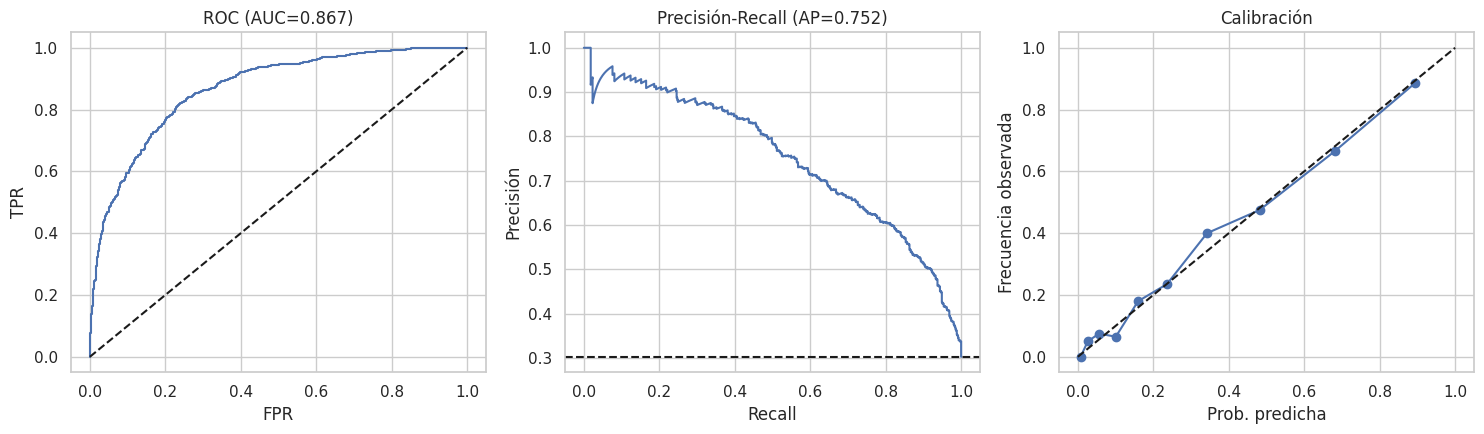

In [28]:
# Incertidumbre del AUC: bootstrap
rng = np.random.default_rng(SEED); yt, pt = y_te2.values, p_te2
aucs = [roc_auc_score(yt[i], pt[i]) for i in (rng.integers(0, len(yt), len(yt)) for _ in range(500))]
print(f"AUC test = {roc_auc_score(yt, pt):.4f}   IC95% [{np.percentile(aucs, 2.5):.4f}, {np.percentile(aucs, 97.5):.4f}]")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
fpr, tpr, _ = roc_curve(y_te2, p_te2); ax[0].plot(fpr, tpr); ax[0].plot([0, 1], [0, 1], "k--")
ax[0].set(title=f"ROC (AUC={roc_auc_score(y_te2, p_te2):.3f})", xlabel="FPR", ylabel="TPR")
pr, rc, _ = precision_recall_curve(y_te2, p_te2); ax[1].plot(rc, pr); ax[1].axhline(tasa2, c="k", ls="--")
ax[1].set(title=f"Precisión-Recall (AP={average_precision_score(y_te2, p_te2):.3f})", xlabel="Recall", ylabel="Precisión")
fr, md_ = calibration_curve(y_te2, p_te2, n_bins=10, strategy="quantile")
ax[2].plot(md_, fr, "o-"); ax[2].plot([0, 1], [0, 1], "k--")
ax[2].set(title="Calibración", xlabel="Prob. predicha", ylabel="Frecuencia observada")
plt.tight_layout(); plt.show()

In [29]:
# ¿Falla el modelo en algún segmento?
seg = X_te2.assign(y=y_te2.values, p=p_te2)
seg["tamano"] = pd.cut(seg["num_trabajadores"], [0, 15, 40, 1e9], labels=["5-15", "16-40", ">40"])
filas = []
for c in ["sector", "tamano"]:
    for k, g in seg.groupby(c, observed=True):
        if g["y"].nunique() == 2:
            filas.append({"segmento": c, "grupo": k, "n": len(g), "tasa_real": g["y"].mean(),
                          "prob_media": g["p"].mean(), "AUC": roc_auc_score(g["y"], g["p"])})
pd.DataFrame(filas).round(3)

,segmento,grupo,n,tasa_real,prob_media,AUC
0,sector,Comercio,534,0.2830,0.2900,0.8450
1,sector,Construcción,178,0.3030,0.3310,0.8860
2,sector,Manufactura,314,0.3340,0.3330,0.8750
3,sector,Servicios,671,0.3000,0.2770,0.8830
4,sector,Tecnología,95,0.3470,0.2810,0.8460
5,sector,Transporte,208,0.2980,0.3180,0.8590
6,tamano,5-15,617,0.3390,0.3380,0.8580
7,tamano,16-40,807,0.2970,0.2970,0.8600
8,tamano,>40,576,0.2730,0.2580,0.8860


**Lectura:** el AUC es estable entre segmentos y las probabilidades predichas coinciden con la frecuencia real (buena calibración). Eso permite usar la probabilidad directamente en una regla de decisión económica.

## 2.6 Valor de negocio: ¿a cuántas empresas contactar?

El **lift** mide cuántas veces mejor que el azar es el modelo en cada decil de riesgo (decil 1 = mayor riesgo).

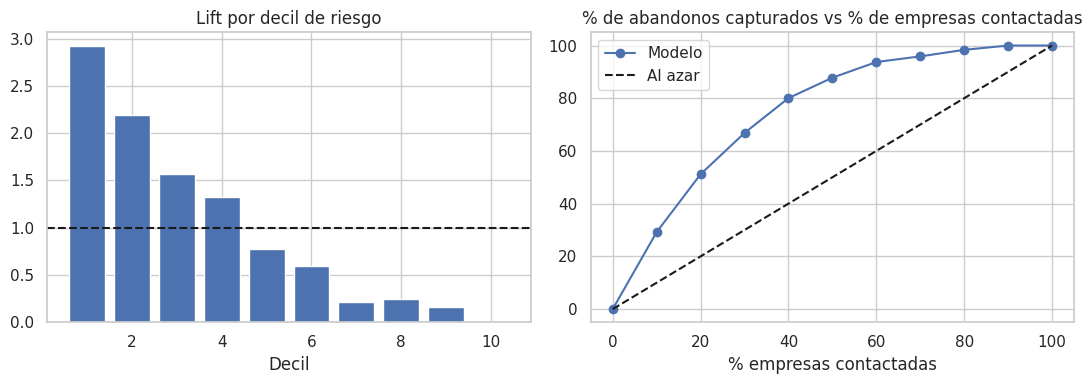

,empresas,abandonan,tasa_real,prob_media,lift,captura_acum_%
decil,,,,,,
1,200,177,0.8850,0.8930,2.9210,29.2080
2,200,133,0.6650,0.6810,2.1950,51.1550
3,200,95,0.4750,0.4820,1.5680,66.8320
4,200,80,0.4000,0.3420,1.3200,80.0330
5,200,47,0.2350,0.2360,0.7760,87.7890
6,200,36,0.1800,0.1600,0.5940,93.7290
7,200,13,0.0650,0.1010,0.2150,95.8750
8,200,15,0.0750,0.0560,0.2480,98.3500
9,200,10,0.0500,0.0260,0.1650,100.0000


In [30]:
def tabla_ganancias(y, p, deciles=10):
    d = pd.DataFrame({"y": np.asarray(y), "p": np.asarray(p)}).sort_values("p", ascending=False).reset_index(drop=True)
    d["decil"] = (np.arange(len(d)) * deciles // len(d)) + 1
    g = d.groupby("decil").agg(empresas=("y", "size"), abandonan=("y", "sum"), tasa_real=("y", "mean"), prob_media=("p", "mean"))
    g["lift"] = g["tasa_real"] / d["y"].mean()
    g["captura_acum_%"] = 100 * g["abandonan"].cumsum() / d["y"].sum()
    return g

g2 = tabla_ganancias(y_te2, p_te2)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(g2.index, g2["lift"]); ax[0].axhline(1, c="k", ls="--"); ax[0].set(title="Lift por decil de riesgo", xlabel="Decil")
ax[1].plot([0] + list(g2.index * 10), [0] + list(g2["captura_acum_%"]), "o-", label="Modelo")
ax[1].plot([0, 100], [0, 100], "k--", label="Al azar"); ax[1].legend()
ax[1].set(title="% de abandonos capturados vs % de empresas contactadas", xlabel="% empresas contactadas")
plt.tight_layout(); plt.show()
g2.round(3)

## 2.7 Decisión económica con supuestos explícitos

Contactar a una empresa vale la pena si su **valor esperado** es positivo:

> `p × efectividad × valor de la empresa retenida − costo de la acción > 0`   ⇔   `p > costo / (efectividad × valor)`

⚠️ **Supuesto S5:** los tres parámetros siguientes son **ilustrativos**. Reemplázalos por las cifras reales y toda la sección se recalcula.

Regla: contactar si p ≥ 37.5%  -> 32.2% de las empresas
Beneficio neto en test con la regla       :       740 M COP
Beneficio neto contactando a TODAS        :      -576 M COP


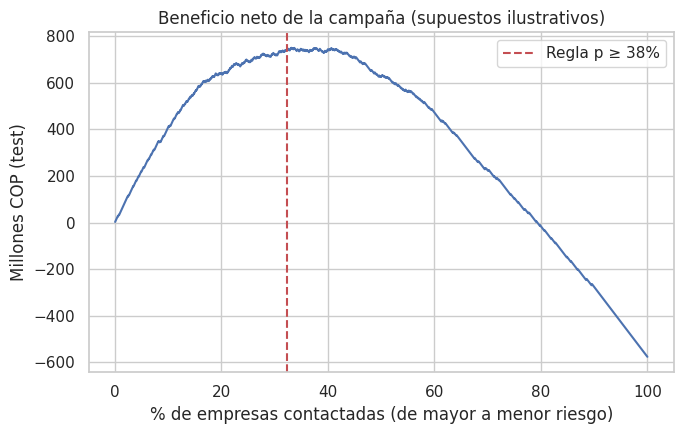

In [31]:
VALOR_EMPRESA_RETENIDA = 20_000_000   # valor anual esperado de conservar una empresa (COP)
COSTO_ACCION = 1_500_000              # costo de una acción de retención por empresa (COP)
EFECTIVIDAD = 0.20                    # prob. de que la acción evite el retiro de una empresa que se iría

corte_ev = COSTO_ACCION / (EFECTIVIDAD * VALOR_EMPRESA_RETENIDA)
orden = np.argsort(-p_te2)
ev_real = np.cumsum(y_te2.values[orden] * EFECTIVIDAD * VALOR_EMPRESA_RETENIDA - COSTO_ACCION)  # con el abandono real en test
n_regla = int((p_te2 >= corte_ev).sum())
benef_regla = float(ev_real[n_regla - 1]) if n_regla else 0.0
benef_todos = float((y_te2.values * EFECTIVIDAD * VALOR_EMPRESA_RETENIDA - COSTO_ACCION).sum())

print(f"Regla: contactar si p ≥ {corte_ev:.1%}  -> {n_regla/len(p_te2):.1%} de las empresas")
print(f"Beneficio neto en test con la regla       : {benef_regla/1e6:>9,.0f} M COP")
print(f"Beneficio neto contactando a TODAS        : {benef_todos/1e6:>9,.0f} M COP")

plt.figure(figsize=(7, 4.5))
plt.plot(np.arange(1, len(ev_real) + 1) / len(ev_real) * 100, ev_real / 1e6)
plt.axvline(100 * n_regla / len(p_te2), c="r", ls="--", label=f"Regla p ≥ {corte_ev:.0%}")
plt.xlabel("% de empresas contactadas (de mayor a menor riesgo)"); plt.ylabel("Millones COP (test)")
plt.title("Beneficio neto de la campaña (supuestos ilustrativos)"); plt.legend(); plt.tight_layout(); plt.show()

In [32]:
# Sensibilidad: el corte depende de los supuestos -> mostrar el rango
sens = []
for ef in [0.10, 0.20, 0.30]:
    for val in [10e6, 20e6, 40e6]:
        c = COSTO_ACCION / (ef * val)
        sens.append({"efectividad": ef, "valor_empresa_M": val / 1e6, "corte_prob": c, "%_empresas_a_contactar": 100 * (p_te2 >= c).mean()})
pd.DataFrame(sens).round(3)

,efectividad,valor_empresa_M,corte_prob,%_empresas_a_contactar
0,0.1000,10.0000,1.5000,0.0000
1,0.1000,20.0000,0.7500,12.3000
2,0.1000,40.0000,0.3750,32.2500
3,0.2000,10.0000,0.7500,12.3000
4,0.2000,20.0000,0.3750,32.2500
5,0.2000,40.0000,0.1880,51.2500
6,0.3000,10.0000,0.5000,23.5000
7,0.3000,20.0000,0.2500,43.4000
8,0.3000,40.0000,0.1250,60.7500


> **🔎 Decisión 3 — priorizar por riesgo con capacidad limitada.** Si el equipo comercial no puede contactar a todas, se recorre la lista de mayor a menor riesgo hasta agotar capacidad; la regla de valor esperado indica el punto a partir del cual contactar **pierde dinero**. La sensibilidad muestra que el resultado depende sobre todo de la efectividad real de la acción: conviene **medirla con un piloto con grupo de control**.

## 2.8 ¿Qué factores explican el abandono?

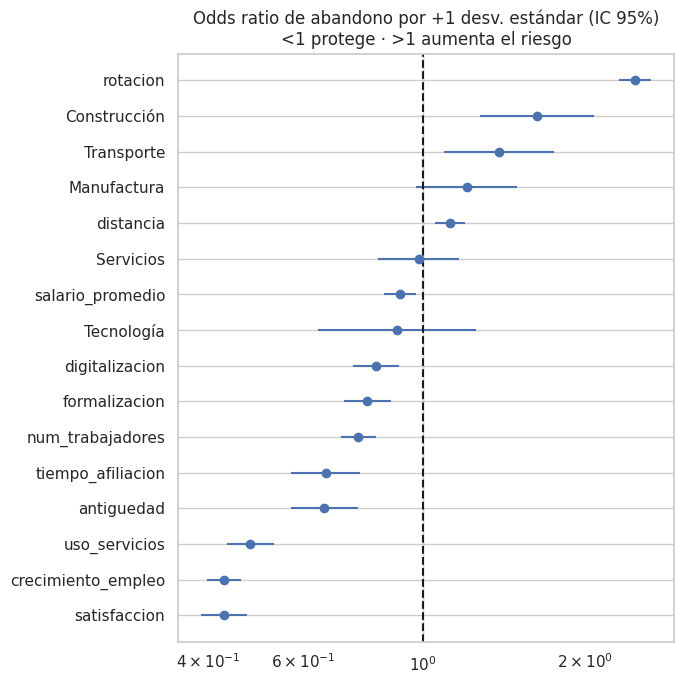

VIF máximo: 3.64 (>5 sería preocupante por colinealidad)


,odds_ratio,IC95_inf,IC95_sup,p_valor
satisfaccion,0.4280,0.3880,0.4730,0.0000
crecimiento_empleo,0.4290,0.3990,0.4610,0.0000
uso_servicios,0.4790,0.4330,0.5290,0.0000
antiguedad,0.6570,0.5700,0.7580,0.0000
tiempo_afiliacion,0.6620,0.5710,0.7670,0.0000
num_trabajadores,0.7590,0.7040,0.8190,0.0000
formalizacion,0.7890,0.7130,0.8740,0.0000
digitalizacion,0.8190,0.7420,0.9050,0.0000
Tecnología,0.8950,0.6380,1.2540,0.5180
salario_promedio,0.9070,0.8490,0.9700,0.0040


In [33]:
# Lente 1: logit con variables estandarizadas -> odds ratio por +1 desviación estándar (comparables entre sí)
from statsmodels.stats.outliers_influence import variance_inflation_factor
Z = X_tr2[num_raw2].copy(); Z = (Z - Z.mean()) / Z.std()
Z = pd.concat([Z, pd.get_dummies(X_tr2["sector"], drop_first=True).astype(float)], axis=1)   # sector base: Comercio
logit2 = sm.Logit(y_tr2, sm.add_constant(Z)).fit(disp=0, cov_type="HC3")
ci = logit2.conf_int()
odds2 = pd.DataFrame({"odds_ratio": np.exp(logit2.params), "IC95_inf": np.exp(ci[0]), "IC95_sup": np.exp(ci[1]),
                      "p_valor": logit2.pvalues}).drop(index="const").sort_values("odds_ratio")

o = odds2
plt.figure(figsize=(7, 7))
plt.errorbar(o["odds_ratio"], range(len(o)), xerr=[o["odds_ratio"] - o["IC95_inf"], o["IC95_sup"] - o["odds_ratio"]], fmt="o")
plt.yticks(range(len(o)), o.index); plt.axvline(1, c="k", ls="--"); plt.xscale("log")
plt.title("Odds ratio de abandono por +1 desv. estándar (IC 95%)\n<1 protege · >1 aumenta el riesgo")
plt.tight_layout(); plt.show()

vif = pd.Series([variance_inflation_factor(Z[num_raw2].values, i) for i in range(len(num_raw2))], num_raw2)
print(f"VIF máximo: {vif.max():.2f} (>5 sería preocupante por colinealidad)")
odds2.round(3)

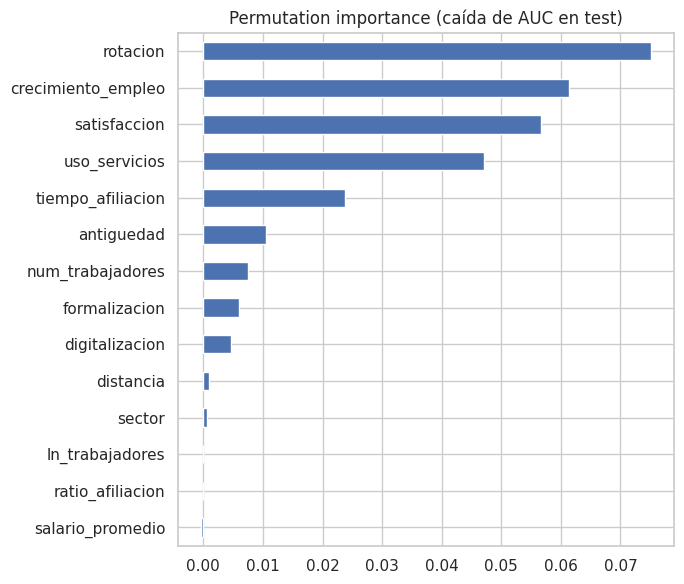

In [34]:
# Lente 2: permutation importance (caída de AUC en test)
from sklearn.inspection import permutation_importance
pi2 = permutation_importance(final2, X_te2, y_te2, scoring="roc_auc", n_repeats=10, random_state=SEED, n_jobs=1)
imp2 = pd.Series(pi2.importances_mean, X2.columns).sort_values()
imp2.plot.barh(figsize=(7, 6), title="Permutation importance (caída de AUC en test)"); plt.tight_layout(); plt.show()

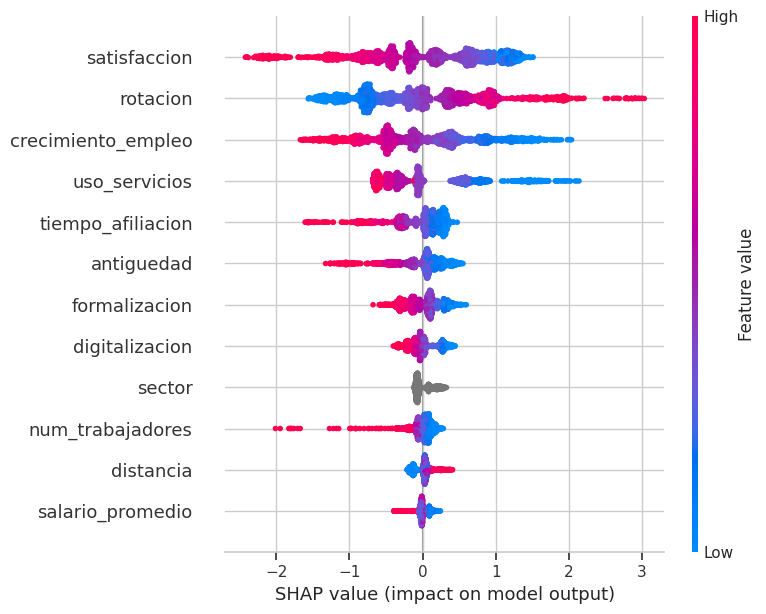

In [35]:
# Lente 3: SHAP sobre LightGBM (revela posibles no linealidades que la logística no vería)
import shap
gbm2 = modelos2["6. LightGBM (ajustado)"]
sv2 = shap.TreeExplainer(gbm2).shap_values(X_te2)
sv2 = sv2[1] if isinstance(sv2, list) else sv2
shap.summary_plot(sv2, X_te2, max_display=12)

## 2.9 Scoring de empresas con "motivos" del riesgo

In [36]:
# Niveles operativos: percentiles calculados sobre calibración (estables)
p_cal2 = final2.predict_proba(X_cal2)[:, 1]
cortes2 = {"alto": float(np.quantile(p_cal2, 0.80)), "medio": float(np.quantile(p_cal2, 0.50))}

def puntuar_empresas(df_nuevas):
    """Probabilidad, nivel de riesgo y los 3 factores que más empujan el riesgo (solo si el modelo es logístico simple)."""
    X = crear_variables_2(df_nuevas)[X2.columns]
    X["sector"] = pd.Categorical(X["sector"].astype(str), categories=list(X2["sector"].cat.categories))
    p = final2.predict_proba(X)[:, 1]
    res = pd.DataFrame({"id_empresa": df_nuevas.get("id_empresa"), "prob_desafiliacion": p,
                        "nivel_riesgo": np.where(p >= cortes2["alto"], "Alto", np.where(p >= cortes2["medio"], "Medio", "Bajo")),
                        "contactar_segun_costo_beneficio": p >= corte_ev})
    if es_logit2 and elegido2.startswith("2."):
        pre, m = final2.named_steps["p"], final2.named_steps["m"]
        Zs = pre.transform(X); Zs = Zs.toarray() if hasattr(Zs, "toarray") else Zs
        contrib = Zs * m.coef_[0]; nombres = pre.get_feature_names_out()
        top = np.argsort(-contrib, axis=1)[:, :3]
        res["factores_principales"] = [", ".join(nombres[j].split("__")[1] for j in fila) for fila in top]
    return res

puntuar_empresas(raw2.head(8)).assign(real=raw2["abandono"].head(8).values).round(3)

,id_empresa,prob_desafiliacion,nivel_riesgo,contactar_segun_costo_beneficio,factores_principales,real
0,1,0.9610,Alto,True,"rotacion, crecimiento_empleo, uso_servicios",1
1,2,0.0740,Bajo,False,"crecimiento_empleo, num_trabajadores, ratio_af...",0
2,3,0.0010,Bajo,False,"satisfaccion, uso_servicios, digitalizacion",0
3,4,0.0320,Bajo,False,"tiempo_afiliacion, antiguedad, num_trabajadores",0
4,5,0.0670,Bajo,False,"uso_servicios, distancia, crecimiento_empleo",0
5,6,0.2620,Medio,False,"crecimiento_empleo, tiempo_afiliacion, antiguedad",0
6,7,0.0380,Bajo,False,"rotacion, tiempo_afiliacion, num_trabajadores",0
7,8,0.1260,Bajo,False,"tiempo_afiliacion, antiguedad, digitalizacion",0


In [37]:
# Los niveles de riesgo sí separan en la práctica (test)
nivel = np.where(p_te2 >= cortes2["alto"], "Alto", np.where(p_te2 >= cortes2["medio"], "Medio", "Bajo"))
pd.DataFrame({"nivel": nivel, "abandono_real": y_te2.values}).groupby("nivel")["abandono_real"].agg(["count", "mean"]).loc[["Alto", "Medio", "Bajo"]]

,count,mean
nivel,,
Alto,394,0.7817
Medio,615,0.3691
Bajo,991,0.0716


### Conclusiones de la Parte 2

| | Resultado (test, 2.000 empresas) |
|---|---|
| Modelo final | **Regresión logística** (parsimonia: igual de buena que LightGBM y explicable) |
| AUC | 0,867 (IC95% 0,850 – 0,882) |
| Decil de mayor riesgo | 88% de abandono real (≈3× la tasa global de 30%) |
| Contactando al 30% de mayor riesgo | se captura ~67% de los abandonos |
| Niveles de riesgo Alto / Medio / Bajo | 78% / 37% / 7% de abandono real |

**Factores asociados** (odds ratio por +1 desv. estándar)
- **Rotación de personal**: principal factor de riesgo (≈ ×2,5 las probabilidades de retiro).
- **Satisfacción, crecimiento del empleo y uso de servicios**: principales protectores (reducen a menos de la mitad).
- Antigüedad y tiempo de afiliación protegen de forma moderada. **Sector** pesa poco (solo Construcción y Transporte destacan). Distancia y salario casi no aportan.
- *Implicación:* dirigir la retención a empresas con alta rotación, bajo uso de servicios y baja satisfacción; no segmentar por sector.

**Limitaciones**
- Parámetros económicos ilustrativos (valor, costo, efectividad): reemplazar con cifras reales.
- Posible causalidad inversa en uso de servicios y satisfacción (S4): confirmar la fecha de medición.
- Asociación, no causalidad: validar con un piloto con grupo de control.
- Sin dimensión temporal: no predice *cuándo* se retira una empresa.

---
# PARTE 3 · Reto 3 — Proyección mensual del recaudo y presupuesto 2026

**Pregunta de negocio:** ¿cuánto se recaudará mes a mes en los próximos 12 meses y cuánto presupuestar?

**Idea central.** El recaudo se descompone de forma exacta en tres piezas:

> **recaudo = trabajadores × salario promedio × tasa efectiva**,  con tasa efectiva = recaudo / masa salarial

- El salario promedio sigue al **salario mínimo (SMMLV)**, que se conoce por decreto a fines de diciembre.
- Los trabajadores crecen de forma lenta y suave.
- La tasa efectiva tiene estacionalidad (enero bajo, diciembre alto).

Un modelo de series de tiempo "puro" no puede anticipar el salto del SMMLV; uno **estructural** sí.

**Supuestos**
- S1. Serie mensual completa 2015-01 a 2025-12 en COP corrientes; se proyecta 2026.
- S2. El SMMLV 2026 se conoce al presupuestar: **1.750.905 (+23,0%, Decreto 1469 de 2025)**. Es un parámetro.
- S3. La relación salario promedio / SMMLV se mantiene en el nivel de los últimos 36 meses.
- S4. Los escenarios conservador y de estrés son ilustrativos (se calibran con 2020) y deben validarse con finanzas.
- S5. Las variables macro se **explican**, no se proyectan: proyectarlas añade más incertidumbre que información.

## 3.1 Carga y control de calidad

In [38]:
H = 12                                   # horizonte (meses)
SHOCK = ("2020-01-01", "2021-12-01")     # ventana COVID: el backtest se reporta con y sin ella
SMMLV_2026 = 1_750_905
MACRO = ["desempleo", "inflacion", "pib", "trm", "precio_petroleo", "indice_confianza"]

d3 = pd.read_excel(DATA_DIR / "dataset_recaudo.xlsx", parse_dates=["fecha"]).set_index("fecha").sort_index().asfreq("MS")
assert d3.isna().sum().sum() == 0 and len(d3) == 132, "Faltan meses o hay nulos"
# Identidad contable: masa salarial = trabajadores × salario promedio
assert np.allclose(d3["masa_salarial"] / (d3["trabajadores"] * d3["salario_promedio"]), 1, rtol=1e-3)

d3["tasa"] = d3["recaudo"] / d3["masa_salarial"]                 # tasa efectiva
d3["k_salario"] = d3["salario_promedio"] / d3["salario_minimo"]   # relación salario promedio / SMMLV
print(f"{d3.index.min():%Y-%m} a {d3.index.max():%Y-%m} | {len(d3)} meses | sin faltantes | identidad contable verificada")
d3.head()

2015-01 a 2025-12 | 132 meses | sin faltantes | identidad contable verificada


,recaudo,empresas,trabajadores,salario_minimo,salario_promedio,masa_salarial,desempleo,inflacion,pib,trm,precio_petroleo,indice_confianza,tasa,k_salario
fecha,,,,,,,,,,,,,,
2015-01-01,46478701032,40820,734036,644350,1674050,1228812965800,9.7339,4.4087,99.8362,"2,875.1400",63.1400,97.2300,0.0378,2.5980
2015-02-01,49215210366,41367,741762,644350,1641916,1217910895992,9.9150,4.4543,100.7332,"2,899.4500",65.1000,101.8800,0.0404,2.5482
2015-03-01,46665373688,41091,741667,644350,1531909,1136166352303,10.3303,4.5145,100.2844,"2,905.5400",72.2100,100.4700,0.0411,2.3774
2015-04-01,49184725954,41267,740846,644350,1685844,1248950784024,10.7450,4.7045,100.6054,"2,932.1800",70.2100,103.6700,0.0394,2.6163
2015-05-01,53929007933,41909,752405,644350,1739668,1308934901540,10.6512,5.0195,102.9726,"2,960.1000",74.8700,104.4500,0.0412,2.6999


In [39]:
d3.describe().T

,count,mean,std,min,25%,50%,75%,max
recaudo,132.0000,"108,381,082,621.9924","50,259,494,580.1979","46,478,701,032.0000","69,967,708,026.5000","86,402,380,730.5000","147,597,493,309.7500","223,821,507,606.0000"
empresas,132.0000,"52,858.9470","7,331.9849","40,820.0000","46,793.2500","50,869.5000","59,736.0000","66,192.0000"
trabajadores,132.0000,"951,484.3409","132,037.9730","734,036.0000","847,813.2500","916,401.5000","1,077,591.5000","1,195,582.0000"
salario_minimo,132.0000,"940,973.5455","243,832.5982","644,350.0000","737,717.0000","877,803.0000","1,160,000.0000","1,423,500.0000"
salario_promedio,132.0000,"2,448,214.8182","640,053.7089","1,531,909.0000","1,950,402.0000","2,280,315.0000","2,997,229.0000","3,786,787.0000"
masa_salarial,132.0000,"2,410,139,971,066.3940","963,797,052,414.1719","1,136,166,352,303.0000","1,632,420,224,917.7500","2,068,255,725,882.0000","3,230,169,094,411.5000","4,391,744,838,671.0000"
desempleo,132.0000,10.4510,1.1635,8.4450,9.5903,10.4539,11.0094,14.1842
inflacion,132.0000,4.2241,0.7167,2.8739,3.6611,4.3008,4.6576,5.9438
pib,132.0000,123.3536,15.3678,99.8362,110.9833,118.4377,136.7992,150.9330
trm,132.0000,"3,323.3163",316.1706,"2,752.6200","3,069.7200","3,335.8050","3,585.4600","4,012.7800"


## 3.2 Comportamiento histórico

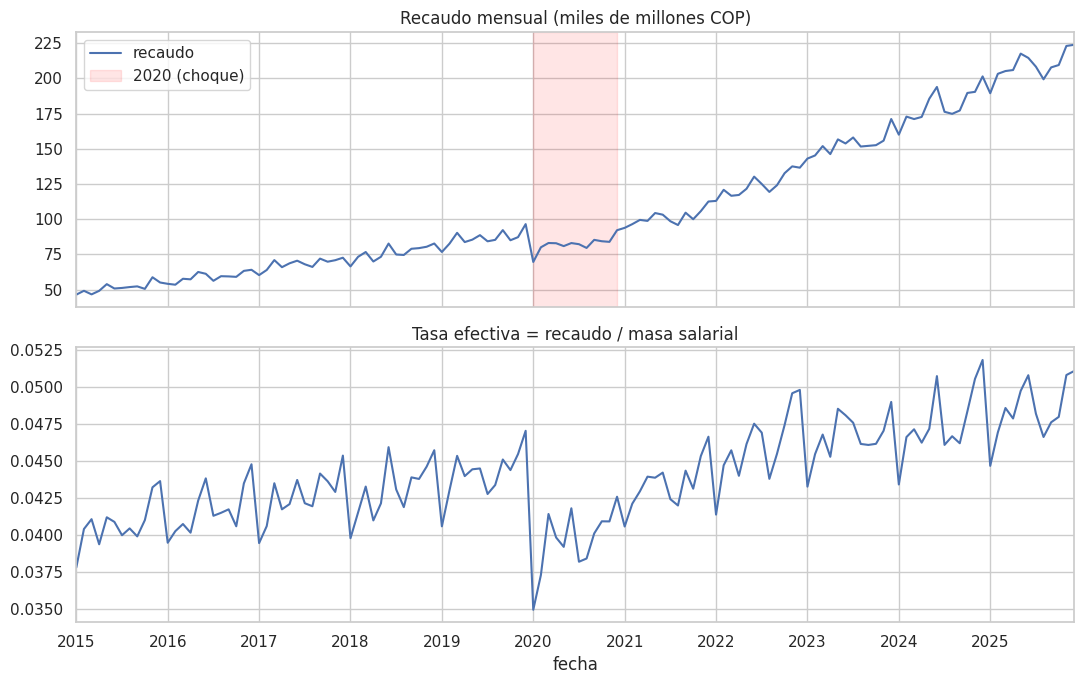

In [40]:
fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
(d3["recaudo"] / 1e9).plot(ax=ax[0], title="Recaudo mensual (miles de millones COP)")
d3["tasa"].plot(ax=ax[1], title="Tasa efectiva = recaudo / masa salarial")
ax[0].axvspan(SHOCK[0], "2020-12-31", color="red", alpha=.1, label="2020 (choque)"); ax[0].legend()
plt.tight_layout(); plt.show()

**Lectura:** tendencia creciente con una **caída clara en 2020** (y rebote en 2021), concentrada en la tasa efectiva, y una tasa que deriva lentamente al alza. La serie también tiene un patrón dentro del año.

Fuerza de estacionalidad (STL): 0.50  (0 = nula, 1 = total)
Efecto estacional por mes (%): {1: -2.8, 2: 1.8, 3: 2.4, 4: -0.5, 5: 4.3, 6: 3.8, 7: -1.7, 8: -4.5, 9: -1.9, 10: -3.1, 11: 0.8, 12: 1.7}


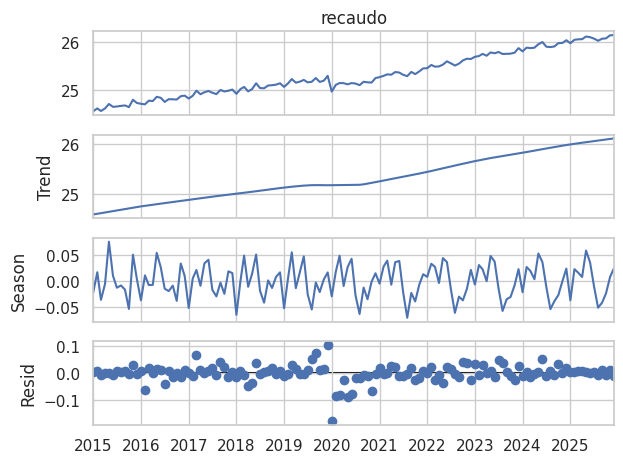

ADF p-valores (ln, nivel): {'recaudo': 0.977, 'masa_salarial': 0.993} -> no estacionarias: hay tendencia


In [41]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller

stl = STL(np.log(d3["recaudo"]), period=12, robust=True).fit()
fuerza = max(0, 1 - stl.resid.var() / (stl.seasonal + stl.resid).var())
perfil = stl.seasonal.groupby(stl.seasonal.index.month).mean().apply(np.exp).sub(1).mul(100)
print(f"Fuerza de estacionalidad (STL): {fuerza:.2f}  (0 = nula, 1 = total)")
print("Efecto estacional por mes (%):", perfil.round(1).to_dict())
stl.plot(); plt.tight_layout(); plt.show()
print("ADF p-valores (ln, nivel):", {c: round(adfuller(np.log(d3[c]))[1], 3) for c in ["recaudo", "masa_salarial"]},
      "-> no estacionarias: hay tendencia")

> **🔎 Decisión 1 — trabajar en logaritmos.** La serie crece de forma multiplicativa (los saltos son proporcionales al nivel) y no es estacionaria. En log, la estacionalidad y las tendencias se vuelven aditivas y los errores se interpretan como porcentajes.

## 3.3 ¿De dónde viene el crecimiento? Descomposición exacta

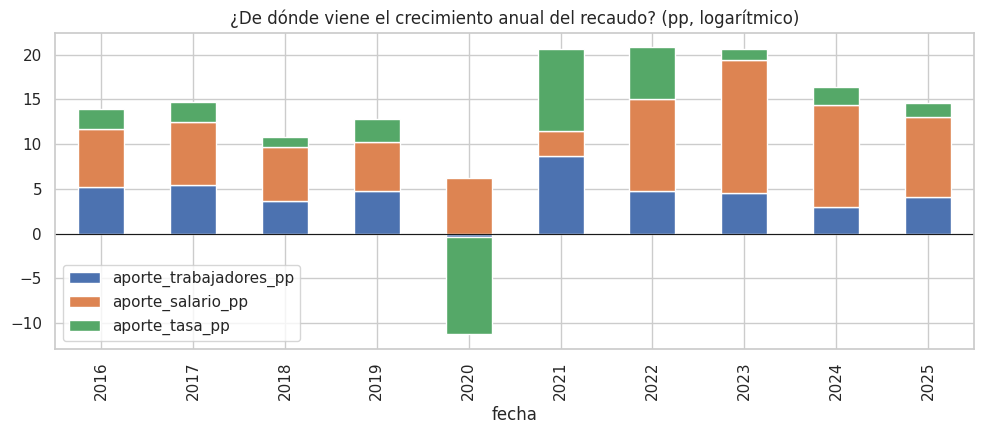

,crec_recaudo_%,aporte_trabajadores_pp,aporte_salario_pp,aporte_tasa_pp
fecha,,,,
2016,13.9000,5.2000,6.5000,2.2000
2017,14.7000,5.4000,7.1000,2.2000
2018,10.8000,3.6000,6.1000,1.1000
2019,12.8000,4.7000,5.5000,2.5000
2020,-5.0000,-0.4000,6.2000,-10.8000
2021,20.6000,8.7000,2.7000,9.2000
2022,20.8000,4.8000,10.3000,5.7000
2023,20.7000,4.5000,14.9000,1.2000
2024,16.4000,3.0000,11.3000,2.1000


In [42]:
anual = d3[["recaudo", "trabajadores", "salario_promedio", "tasa"]].resample("YS").agg(
    {"recaudo": "sum", "trabajadores": "mean", "salario_promedio": "mean", "tasa": "mean"})
contrib = np.log(anual).diff().dropna() * 100
# La tasa se calcula como residuo para que la identidad sea exacta: Δln(recaudo) = Δln(trab) + Δln(salario) + Δln(tasa)
contrib["tasa"] = np.log(anual["recaudo"]).diff().dropna() * 100 - contrib["trabajadores"] - contrib["salario_promedio"]
contrib.columns = ["crec_recaudo_%", "aporte_trabajadores_pp", "aporte_salario_pp", "aporte_tasa_pp"]
contrib.index = contrib.index.year
contrib[["aporte_trabajadores_pp", "aporte_salario_pp", "aporte_tasa_pp"]].plot.bar(
    stacked=True, figsize=(10, 4.5), title="¿De dónde viene el crecimiento anual del recaudo? (pp, logarítmico)")
plt.axhline(0, c="k", lw=.8); plt.tight_layout(); plt.show()
contrib.round(1)

**Lectura:** el **salario** es el motor del crecimiento (en 2023, 14,9 de 20,7 puntos); el empleo aporta de 3 a 5 puntos por año; y la tasa efectiva explica casi todo el desplome de 2020 (−10,8 pp) y el rebote de 2021.

## 3.4 Factores que influyen: salario mínimo, empleo y macro

Elasticidad salario_promedio vs SMMLV = 1.01  (IC95% 1.00–1.02),  R² = 0.993
Relación k = salario_promedio / SMMLV: media 2.601, desv. 0.056, rango 2.38–2.76


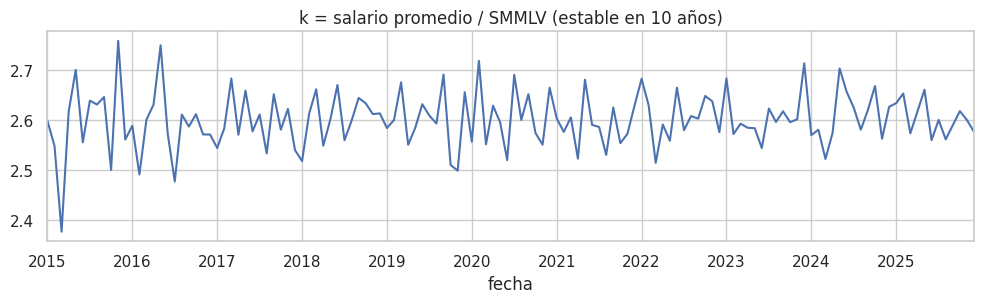

In [43]:
# (a) ¿El salario promedio sigue al SMMLV? Elasticidad en logs, errores robustos a autocorrelación (HAC)
m_sal = sm.OLS(np.log(d3["salario_promedio"]), sm.add_constant(np.log(d3["salario_minimo"]))).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
ic = m_sal.conf_int().loc["salario_minimo"].values
print(f"Elasticidad salario_promedio vs SMMLV = {m_sal.params['salario_minimo']:.2f}  (IC95% {ic[0]:.2f}–{ic[1]:.2f}),  R² = {m_sal.rsquared:.3f}")
print(f"Relación k = salario_promedio / SMMLV: media {d3['k_salario'].mean():.3f}, desv. {d3['k_salario'].std():.3f}, "
      f"rango {d3['k_salario'].min():.2f}–{d3['k_salario'].max():.2f}")

d3["k_salario"].plot(figsize=(10, 3.2), title="k = salario promedio / SMMLV (estable en 10 años)"); plt.tight_layout(); plt.show()

> **🔎 Decisión 2 — el SMMLV es el insumo clave.** Una elasticidad ≈ 1 con k estable significa que cada reajuste del SMMLV se traslada casi 1 a 1 al salario promedio. Por eso conocer el decreto de diciembre es información de altísimo valor para el presupuesto (se cuantifica en el backtest).

In [44]:
# (b) Correlaciones entre VARIACIONES ANUALES (evita correlaciones espurias entre tendencias), con rezagos de 0, 3 y 6 meses
yoy = np.log(d3[["recaudo", "trabajadores", "salario_promedio", "salario_minimo", "masa_salarial"]]).diff(12)
yoy["tasa_dif"] = d3["tasa"].diff(12)
mac_yoy = pd.DataFrame({"desempleo": d3["desempleo"].diff(12), "inflacion": d3["inflacion"].diff(12),
                        "pib": np.log(d3["pib"]).diff(12), "trm": np.log(d3["trm"]).diff(12),
                        "precio_petroleo": np.log(d3["precio_petroleo"]).diff(12),
                        "indice_confianza": d3["indice_confianza"].diff(12)})
filas = [{"variable": v, "objetivo": o, "rezago_meses": lag, "corr": mac_yoy[v].shift(lag).corr(yoy[o])}
         for v in MACRO for o in ["recaudo", "trabajadores"] for lag in [0, 3, 6]]
corr_mac = pd.DataFrame(filas)
corr_mac.pivot_table(index="variable", columns=["objetivo", "rezago_meses"], values="corr").round(2)

objetivo         recaudo                 trabajadores                
rezago_meses           0       3       6            0       3       6
variable                                                             
desempleo        -0.5900 -0.2800 -0.1000      -0.8000 -0.3900 -0.1000
indice_confianza  0.4300  0.2500 -0.0700       0.6700  0.4000  0.0100
inflacion         0.2100  0.1200 -0.0400       0.4200  0.2600  0.0200
pib               0.7100  0.5000  0.3000       0.9100  0.5500  0.2300
precio_petroleo   0.0300  0.0000  0.0500       0.0100 -0.0200  0.1100
trm               0.0100 -0.0600 -0.1000       0.1500 -0.0300 -0.1900

In [45]:
# (c) Causalidad de Granger: ¿los cambios macro ANTICIPAN el crecimiento del recaudo? (rezagos 1-6, corrección Bonferroni)
import contextlib, io
from statsmodels.tsa.stattools import grangercausalitytests
g_rows = []
for v in MACRO:
    z = pd.concat([yoy["recaudo"], mac_yoy[v]], axis=1).dropna()
    with contextlib.redirect_stdout(io.StringIO()):
        res = grangercausalitytests(z, maxlag=6)
    g_rows.append({"variable": v, "p_min_rezagos_1a6": min(res[l][0]["ssr_ftest"][1] for l in range(1, 7))})
gr = pd.DataFrame(g_rows); gr["p_ajustado_bonferroni"] = (gr["p_min_rezagos_1a6"] * 6).clip(upper=1)
gr.round(4)

,variable,p_min_rezagos_1a6,p_ajustado_bonferroni
0,desempleo,0.0605,0.3632
1,inflacion,0.0906,0.5436
2,pib,0.0025,0.0152
3,trm,0.2294,1.0000
4,precio_petroleo,0.3147,1.0000
5,indice_confianza,0.0196,0.1175


In [46]:
# (d) Regresión del crecimiento anual: ¿cuánto explican SMMLV, empleo y tasa?
Z = pd.concat([yoy["recaudo"], yoy["salario_minimo"], yoy["trabajadores"], yoy["tasa_dif"]], axis=1).dropna()
Z.columns = ["d12_recaudo", "d12_smmlv", "d12_trabajadores", "d12_tasa"]
m_g = sm.OLS(Z["d12_recaudo"], sm.add_constant(Z[["d12_smmlv", "d12_trabajadores", "d12_tasa"]])).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
print(f"R² = {m_g.rsquared:.3f}")
pd.DataFrame({"coef": m_g.params, "p_valor": m_g.pvalues}).round(4)

R² = 0.887


,coef,p_valor
const,-0.0013,0.8669
d12_smmlv,1.0066,0.0000
d12_trabajadores,1.0241,0.0000
d12_tasa,22.6216,0.0000


**Lectura:** el crecimiento del recaudo se explica casi 1 a 1 por el reajuste del SMMLV y el crecimiento del empleo (coeficientes ≈ 1; R² ≈ 0,89). El **PIB** es la única variable macro que anticipa el crecimiento (Granger, significativo tras Bonferroni) y opera **vía empleo** (correlación 0,91 con el crecimiento de trabajadores). TRM, petróleo e inflación no aportan.

> **🔎 Decisión 3 — la macro explica pero no entra al modelo.** Para usarla al proyectar habría que pronosticar antes PIB, desempleo, etc., con su propio error. El SMMLV, en cambio, es un dato conocido: entra directo.

## 3.5 Modelos candidatos

1. **Estructural** (el propuesto): trabajadores × (k · SMMLV) × tasa. Se evalúa con SMMLV *conocido* (situación real en diciembre) y *desconocido* (para medir su valor).
2. **Holt-Winters (ETS)** amortiguado sobre ln(recaudo).
3. **SARIMA(1,1,1)(0,1,1,12)** sobre ln(recaudo).
4. **Estacional naive + deriva**: repite los últimos 12 meses escalados por el crecimiento del último año (la referencia simple que hay que superar).

In [47]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

def ajustar_estructural(hist, smin_futuro, pass_through=1.0, ajuste_empleo=0.0, ajuste_tasa=0.0, k_ventana=36):
    """trabajadores × salario_promedio × tasa.
    - salario_promedio = k × SMMLV efectivo (k = media de los últimos 36 meses). pass_through<1: no todo el reajuste llega al salario.
    - trabajadores: deriva lineal en logs con la tendencia de los últimos 24 meses.
    - tasa: Holt-Winters aditivo amortiguado sobre ln(tasa) con estacionalidad anual.
    - ajuste_empleo / ajuste_tasa: desplazamientos en log (para escenarios)."""
    n = len(smin_futuro)
    k = hist["k_salario"].iloc[-k_ventana:].mean()
    smin_ref = hist["salario_minimo"].iloc[-1]
    smin_eff = smin_ref * (smin_futuro / smin_ref) ** pass_through
    ln_t = np.log(hist["trabajadores"]); g = (ln_t.iloc[-1] - ln_t.iloc[-25]) / 24
    trab = np.exp(ln_t.iloc[-1] + g * np.arange(1, n + 1) + ajuste_empleo)
    ets = ExponentialSmoothing(np.log(hist["tasa"]), trend="add", damped_trend=True, seasonal="add", seasonal_periods=12).fit()
    tasa = np.exp(ets.forecast(n).values + ajuste_tasa)
    return trab * (k * smin_eff) * tasa

def ref_snaive_drift(hist):
    y = hist["recaudo"]; return y.iloc[-12:].values * (y.iloc[-12:].sum() / y.iloc[-24:-12].sum())

def ref_ets(hist, n=H):
    m = ExponentialSmoothing(np.log(hist["recaudo"]), trend="add", damped_trend=True, seasonal="add", seasonal_periods=12).fit()
    return np.exp(m.forecast(n).values)

def ref_sarima(hist, n=H):
    m = SARIMAX(np.log(hist["recaudo"]), order=(1, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False)
    return np.exp(m.forecast(n).values)
print("Modelos definidos")

Modelos definidos


## 3.6 Validación: backtest de origen rodante

Se imita exactamente lo que ocurre en la realidad: **cada diciembre** (2018–2024) se congela la historia, se proyectan los 12 meses siguientes y se compara con lo que pasó. Se usan orígenes de diciembre porque es cuando el SMMLV del año siguiente ya es conocido.

In [48]:
filas = []
for o in pd.date_range("2018-12-01", "2024-12-01", freq="12MS"):
    hist = d3.loc[:o]; test = d3.loc[o + pd.offsets.MonthBegin(1):].iloc[:H]
    if len(test) < H: continue
    real = test["recaudo"].values
    preds = {"Estructural (SMMLV conocido)": ajustar_estructural(hist, test["salario_minimo"].values),
             "Estructural (SMMLV desconocido)": ajustar_estructural(hist, np.repeat(hist["salario_minimo"].iloc[-1], H)),
             "Holt-Winters (ETS)": ref_ets(hist), "SARIMA": ref_sarima(hist), "Estacional naive + deriva": ref_snaive_drift(hist)}
    choque = (test.index.min() <= pd.Timestamp(SHOCK[1])) and (test.index.max() >= pd.Timestamp(SHOCK[0]))
    for nombre, p in preds.items():
        filas.append({"origen": o, "anio_proyectado": o.year + 1, "modelo": nombre, "ventana_choque": choque,
                      "MAPE": np.mean(np.abs(p / real - 1)), "error_total_anual": p.sum() / real.sum() - 1,
                      "log_errores": list(np.log(real / p))})
bt = pd.DataFrame(filas)

def resumen(sub, etiqueta):
    g = sub.groupby("modelo").agg(MAPE_medio=("MAPE", "mean"), MAPE_max=("MAPE", "max"),
                                  error_total_abs=("error_total_anual", lambda s: s.abs().mean()),
                                  sesgo_total=("error_total_anual", "mean"), folds=("MAPE", "size"))
    g.insert(0, "periodo", etiqueta); return g

res_bt = pd.concat([resumen(bt, "todos los folds"), resumen(bt[~bt["ventana_choque"]], "sin choque 2020-21")]).reset_index()
res_bt.sort_values(["periodo", "MAPE_medio"]).round(3)

,modelo,periodo,MAPE_medio,MAPE_max,error_total_abs,sesgo_total,folds
6,Estructural (SMMLV conocido),sin choque 2020-21,0.0310,0.0540,0.0230,-0.0070,5
5,Estacional naive + deriva,sin choque 2020-21,0.0370,0.0510,0.0170,0.0080,5
9,SARIMA,sin choque 2020-21,0.0460,0.0890,0.0400,-0.0330,5
8,Holt-Winters (ETS),sin choque 2020-21,0.0530,0.1030,0.0480,-0.0440,5
7,Estructural (SMMLV desconocido),sin choque 2020-21,0.1020,0.1390,0.1030,-0.1030,5
1,Estructural (SMMLV conocido),todos los folds,0.0680,0.1890,0.0620,0.0030,7
3,Holt-Winters (ETS),todos los folds,0.0810,0.1710,0.0780,-0.0260,7
0,Estacional naive + deriva,todos los folds,0.0870,0.2260,0.0720,0.0010,7
4,SARIMA,todos los folds,0.0870,0.1900,0.0820,-0.0240,7
2,Estructural (SMMLV desconocido),todos los folds,0.1130,0.1600,0.1140,-0.0790,7


In [49]:
bt.pivot(index="anio_proyectado", columns="modelo", values="MAPE").round(3)

modelo,Estacional naive + deriva,Estructural (SMMLV conocido),Estructural (SMMLV desconocido),Holt-Winters (ETS),SARIMA
anio_proyectado,,,,,
2019,0.0370,0.0240,0.0660,0.0270,0.0320
2020,0.1960,0.1890,0.1220,0.1710,0.1900
2021,0.2260,0.1310,0.1600,0.1350,0.1900
2022,0.0360,0.0540,0.1390,0.1030,0.0890
2023,0.0370,0.0370,0.1090,0.0810,0.0610
2024,0.0510,0.0230,0.1170,0.0320,0.0270
2025,0.0230,0.0170,0.0810,0.0190,0.0200


**Lectura:**
- **Sin los años de choque** (5 folds), el estructural tiene el menor MAPE (≈3,1%) frente a 3,7% de la referencia simple, 4,6% de SARIMA y 5,3% de Holt-Winters.
- **Con todos los años** el error sube (≈6,8%) porque **ningún modelo anticipó 2020**.
- **Sin conocer el SMMLV** el mismo modelo estructural se triplica en error (≈10%): conocer el decreto es la información más valiosa.
- Con solo 5 folds limpios, la ventaja sobre la referencia simple en el **total anual** no es concluyente (2,3% vs 1,7%); la ventaja real del estructural es que **reacciona al SMMLV**, algo que las referencias no pueden hacer.

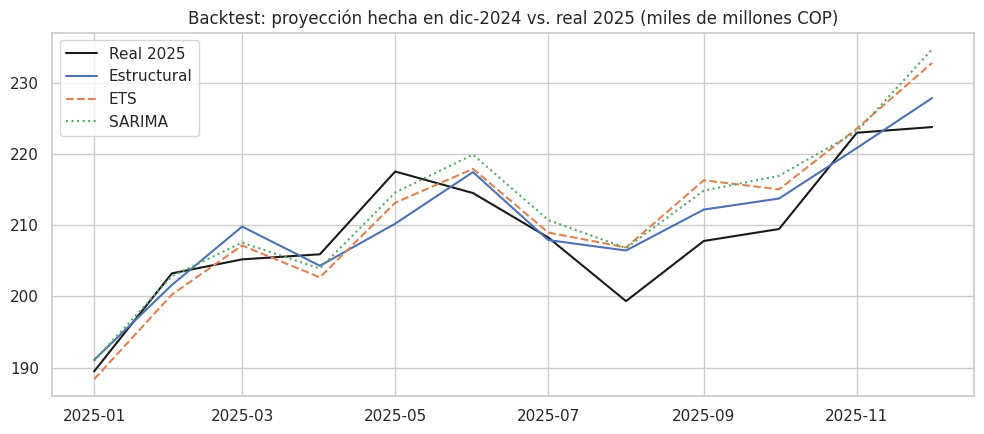

In [50]:
# Visual del último fold: proyección hecha en dic-2024 vs. real 2025
o = pd.Timestamp("2024-12-01"); hist = d3.loc[:o]; test = d3.loc[o + pd.offsets.MonthBegin(1):].iloc[:H]
plt.figure(figsize=(10, 4.5))
plt.plot(test.index, test["recaudo"] / 1e9, "k", label="Real 2025")
plt.plot(test.index, ajustar_estructural(hist, test["salario_minimo"].values) / 1e9, label="Estructural")
plt.plot(test.index, ref_ets(hist) / 1e9, "--", label="ETS"); plt.plot(test.index, ref_sarima(hist) / 1e9, ":", label="SARIMA")
plt.title("Backtest: proyección hecha en dic-2024 vs. real 2025 (miles de millones COP)"); plt.legend(); plt.tight_layout(); plt.show()

## 3.7 Proyección 2026: escenarios y bandas

**Bandas:** se construyen con los errores mensuales del backtest en ventanas **sin choque** (P5, P10, P90, P95).
**Escenarios:**
- **Base:** el reajuste del SMMLV se transmite al 100% (lo histórico: elasticidad ≈ 1).
- **Conservador:** transmisión del 70% y mitad del choque de 2020 en empleo y tasa.
- **Estrés:** transmisión del 70% y choque completo tipo 2020.

> ⚠️ El reajuste de 2026 (+23,0%) supera el máximo histórico de la muestra (+16%): la transmisión al salario es una **extrapolación**. El 70% del conservador es una decisión de prudencia, no un valor estimado.

In [51]:
CAMPEON = "Estructural (SMMLV conocido)"
errs_ok = np.concatenate(bt[(bt["modelo"] == CAMPEON) & (~bt["ventana_choque"])]["log_errores"].tolist())
q = {p: float(np.quantile(errs_ok, p)) for p in [0.05, 0.10, 0.50, 0.90, 0.95]}
print(f"Errores mensuales del campeón (sin choque): P5 {np.exp(q[0.05])-1:+.1%} | P10 {np.exp(q[0.10])-1:+.1%} | "
      f"P90 {np.exp(q[0.90])-1:+.1%} | P95 {np.exp(q[0.95])-1:+.1%}")

fechas = pd.date_range(d3.index[-1] + pd.offsets.MonthBegin(1), periods=H, freq="MS")
smmlv_ref = d3["salario_minimo"].iloc[-1]
smin_fut = np.repeat(float(SMMLV_2026), H)                         # el SMMLV aplica de enero a diciembre
print(f"SMMLV {smmlv_ref:,.0f} -> {SMMLV_2026:,.0f}  ({SMMLV_2026/smmlv_ref-1:+.1%}) | máximo reajuste histórico en la muestra: {d3['salario_minimo'].pct_change(12).max():+.1%}")

# Choques calibrados con 2020 (supuesto S4)
choque_empleo = float(np.log(d3.loc["2020-01-01", "trabajadores"] / d3.loc["2019-12-01", "trabajadores"]))
choque_tasa = float(np.log(d3.loc["2020", "tasa"].mean() / d3.loc["2019", "tasa"].mean()))
escenarios = {"Base": dict(pass_through=1.0, ajuste_empleo=0.0, ajuste_tasa=0.0),
              "Conservador": dict(pass_through=0.7, ajuste_empleo=choque_empleo / 2, ajuste_tasa=choque_tasa / 2),
              "Estrés (tipo 2020)": dict(pass_through=0.7, ajuste_empleo=choque_empleo, ajuste_tasa=choque_tasa)}
proy = pd.DataFrame(index=fechas)
for nombre, kw in escenarios.items():
    proy[nombre] = ajustar_estructural(d3, smin_fut, **kw)
for p_, etiqueta in [(0.05, "Base_P05"), (0.10, "Base_P10"), (0.90, "Base_P90"), (0.95, "Base_P95")]:
    proy[etiqueta] = proy["Base"] * np.exp(q[p_])
proy["Ref_ETS_sin_SMMLV"] = ref_ets(d3)
(proy / 1e9).round(1)

Errores mensuales del campeón (sin choque): P5 -5.6% | P10 -3.5% | P90 +6.5% | P95 +7.7%
SMMLV 1,423,500 -> 1,750,905  (+23.0%) | máximo reajuste histórico en la muestra: +16.0%


,Base,Conservador,Estrés (tipo 2020),Base_P05,Base_P10,Base_P90,Base_P95,Ref_ETS_sin_SMMLV
2026-01-01,245.4000,213.0000,196.8000,231.5000,236.9000,261.4000,264.3000,213.0000
2026-02-01,258.9000,224.8000,207.7000,244.3000,250.0000,275.8000,278.9000,226.3000
2026-03-01,269.5000,234.0000,216.2000,254.3000,260.2000,287.1000,290.3000,233.2000
2026-04-01,262.8000,228.2000,210.9000,248.0000,253.8000,280.0000,283.1000,228.3000
2026-05-01,270.8000,235.2000,217.3000,255.6000,261.5000,288.5000,291.7000,239.8000
2026-06-01,280.0000,243.1000,224.6000,264.2000,270.3000,298.3000,301.6000,244.0000
2026-07-01,267.7000,232.4000,214.7000,252.6000,258.4000,285.1000,288.3000,233.9000
2026-08-01,265.3000,230.4000,212.8000,250.4000,256.1000,282.6000,285.7000,230.5000
2026-09-01,272.7000,236.8000,218.8000,257.3000,263.3000,290.5000,293.7000,240.5000
2026-10-01,274.8000,238.6000,220.5000,259.4000,265.4000,292.8000,296.0000,239.1000


In [52]:
rec_2025 = d3["recaudo"].iloc[-12:].sum()
tot = pd.DataFrame({"total_2026_miles_millones": proy.sum() / 1e9})
tot["crecimiento_vs_2025_%"] = (proy.sum() / rec_2025 - 1) * 100
print(f"Recaudo 2025: {rec_2025/1e9:,.0f} miles de millones COP")
tot.round(1)

Recaudo 2025: 2,508 miles de millones COP


,total_2026_miles_millones,crecimiento_vs_2025_%
Base,"3,246.0000",29.4000
Conservador,"2,818.5000",12.4000
Estrés (tipo 2020),"2,604.0000",3.8000
Base_P05,"3,063.2000",22.2000
Base_P10,"3,133.9000",25.0000
Base_P90,"3,457.9000",37.9000
Base_P95,"3,496.3000",39.4000
Ref_ETS_sin_SMMLV,"2,835.2000",13.1000


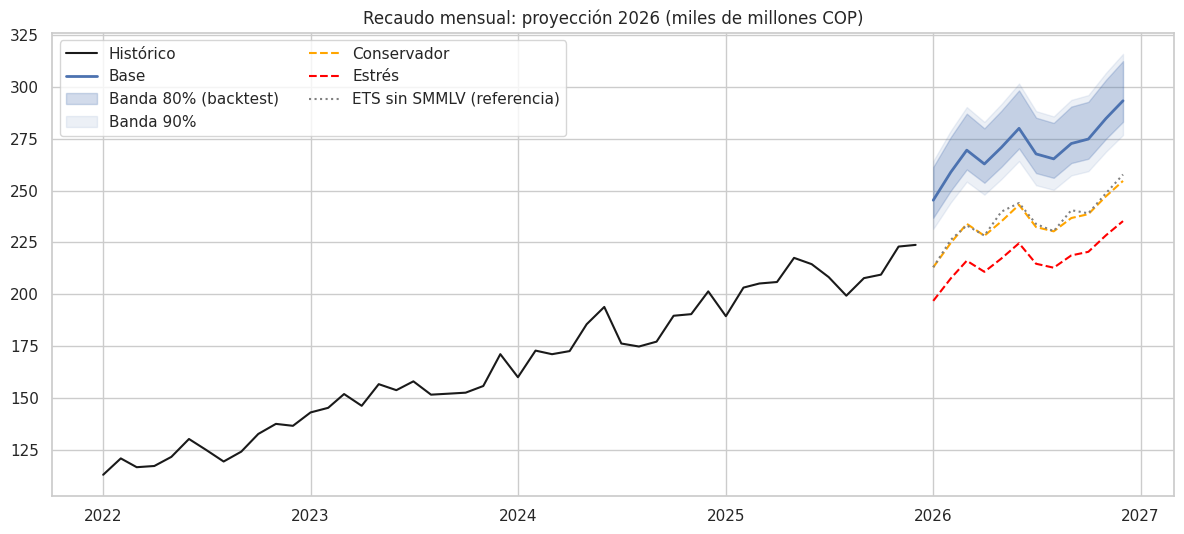

In [53]:
plt.figure(figsize=(12, 5.5))
h = d3["recaudo"].loc["2022":] / 1e9
plt.plot(h.index, h, c="k", label="Histórico")
plt.plot(proy.index, proy["Base"] / 1e9, c="C0", lw=2, label="Base")
plt.fill_between(proy.index, proy["Base_P10"] / 1e9, proy["Base_P90"] / 1e9, color="C0", alpha=.25, label="Banda 80% (backtest)")
plt.fill_between(proy.index, proy["Base_P05"] / 1e9, proy["Base_P95"] / 1e9, color="C0", alpha=.1, label="Banda 90%")
plt.plot(proy.index, proy["Conservador"] / 1e9, c="orange", ls="--", label="Conservador")
plt.plot(proy.index, proy["Estrés (tipo 2020)"] / 1e9, c="red", ls="--", label="Estrés")
plt.plot(proy.index, proy["Ref_ETS_sin_SMMLV"] / 1e9, c="gray", ls=":", label="ETS sin SMMLV (referencia)")
plt.title("Recaudo mensual: proyección 2026 (miles de millones COP)"); plt.legend(ncol=2); plt.tight_layout(); plt.show()

## 3.8 Recomendación para el presupuesto y seguimiento

In [54]:
base_tot = proy["Base"].sum(); p10_tot = proy["Base_P10"].sum(); estres_tot = proy["Estrés (tipo 2020)"].sum()
print(f"1) Meta de ingresos (Base)        : {base_tot/1e9:>7,.0f} miles de millones  ({base_tot/rec_2025-1:+.1%} vs 2025)")
print(f"2) Gasto comprometido (hasta P10) : {p10_tot/1e9:>7,.0f} miles de millones")
print(f"3) Piso de estrés (tipo 2020)     : {estres_tot/1e9:>7,.0f} miles de millones")
print(f"\nAlerta de desviación mensual: recaudo por debajo de {np.exp(q[0.05])-1:+.1%} o por encima de {np.exp(q[0.95])-1:+.1%} del Base (P5/P95 del backtest)")
print("Alerta de transmisión: si k = salario_promedio / SMMLV cae por debajo de ~2,45 durante dos meses seguidos -> pasar al Conservador")

1) Meta de ingresos (Base)        :   3,246 miles de millones  (+29.4% vs 2025)
2) Gasto comprometido (hasta P10) :   3,134 miles de millones
3) Piso de estrés (tipo 2020)     :   2,604 miles de millones

Alerta de desviación mensual: recaudo por debajo de -5.6% o por encima de +7.7% del Base (P5/P95 del backtest)
Alerta de transmisión: si k = salario_promedio / SMMLV cae por debajo de ~2,45 durante dos meses seguidos -> pasar al Conservador


### Conclusiones de la Parte 3

| Escenario | Total 2026 (miles de millones COP) | Vs. 2025 |
|---|---|---|
| **Base** (SMMLV +23%) | **≈ 3.246** | +29,4% |
| Banda 80% del Base | ≈ 3.134 – 3.458 | +25% a +38% |
| Conservador | ≈ 2.818 | +12,4% |
| Estrés (tipo 2020) | ≈ 2.604 | +3,8% |

**Recomendación**
1. **Meta de ingresos:** escenario Base.
2. **Gasto comprometido (fijo):** hasta el P10 del Base; lo que quede por encima se condiciona al cumplimiento del recaudo.
3. **Seguimiento mensual desde enero:** la relación k = salario promedio / SMMLV (debería estar cerca de 2,6) revela rápido si el reajuste del 23% se está transmitiendo; si no, pasar al Conservador.

**Limitaciones**
- **Extrapolación:** +23% supera el máximo histórico (+16%). La diferencia entre Base y Conservador (~430 miles de millones) depende casi toda de cuánto del reajuste llega al salario promedio.
- Escenarios conservador y estrés son supuestos propios, calibrados con 2020; validar con finanzas.
- Bandas basadas en pocos años sin choque (60 errores mensuales correlacionados entre sí); un choque tipo 2020 solo está en el escenario de estrés.
- Precios corrientes: no se separa el efecto inflacionario del real.
- Asociación, no causalidad entre macro y recaudo.

---
## Cierre
Las tres partes comparten la misma lógica de trabajo: **entender el negocio → explorar → probar alternativas con validación honesta → elegir con criterio (precisión, explicabilidad, costo) → comunicar resultados con incertidumbre y limitaciones explícitas.**